In [1]:
import random
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.distributions.categorical import Categorical
from torch.distributions.normal import Normal
import gymnasium as gym
from gymnasium import spaces
from gymnasium.wrappers import FlattenObservation, TransformAction
from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import BaseCallback
from sb3_contrib import RecurrentPPO

from rl_firm.env import BaselineABMEnv, make_sb_env, make_custom_env
from rl_firm.ppo_base import PPOAgent
from rl_firm.ppo_lstm import RecurrentPPOAgent
from rl_firm.ppo_lstm_bounded import RecurrentPPOAgent as SquashedLSTMAgent

## Evaluate function

In [2]:
def get_ranking(firm):
    return sorted(firm.model.firms,
                  key=lambda f: f.last_month_profit,
                  reverse=True).index(firm) + 1

def get_model_from_env(env):
    # Get the model from the wrapped model
    while True:
        if hasattr(env, '_model'):
            return env._model
        elif hasattr(env, 'env'):
            env = env.env
        else:
            raise Exception('Not ABM env')

def evaluate(env, policy, years=100, seed=50):
    obs, info = env.reset(seed=seed)
    model = get_model_from_env(env)
    parameters = model.parameters
    learning_firm = model.learning_firms[0]
    stats = {
        'revenues': [],
        'profits': [],
        'rankings': [],
        'wage_rates': [],
        'goods_prices': [],
        'employee_counts': [],
        'customer_counts': [],
        'inventories': [],
        'wage_adjustments': [],
        'price_adjustments': [],
        'hr_actions': [],
        'rewards': []
    }
    
    def collect_stats(action, reward):
        stats['revenues'].append(learning_firm.last_month_revenue)
        stats['profits'].append(learning_firm.last_month_profit)
        stats['rankings'].append(get_ranking(learning_firm))
        stats['wage_rates'].append(learning_firm.wage_rate)
        stats['goods_prices'].append(learning_firm.goods_price)
        stats['employee_counts'].append(learning_firm.employee_count)
        stats['customer_counts'].append(learning_firm.customer_count)
        stats['inventories'].append(learning_firm.inventories)
        if 'hr_action' in action:
            stats['hr_actions'].append(int(np.clip(np.round(action['hr_action']), 0, 2)))
            stats['price_adjustments'].append(action['price_adjustment'])
            stats['wage_adjustments'].append(action['wage_adjustment'])
        else:
            stats['hr_actions'].append(int(np.clip(np.round(action[0]), 0, 2)))
            stats['price_adjustments'].append(action[1])
            stats['wage_adjustments'].append(action[2])
        stats['rewards'].append(reward)

    # Run for n years
    for _ in range(years * 12):
        action = policy(obs)
        obs, reward, terminated, truncated, _ = env.step(action)
        collect_stats(action, reward)
        if terminated:
            print('Terminated! Went belly up')
            break
        if truncated:
            print('Truncated! Unprofitable')
            break

    print(f'Firm survived for {len(stats['profits']) // 12} years, making a total amount of {sum(stats['profits'])} of profit, with total reward {sum(stats['rewards'])}')
    return stats, model

def evaluate_lstm(env, policy, years=100, seed=50):
    obs, info = env.reset(seed=seed)
    model = get_model_from_env(env)
    parameters = model.parameters
    learning_firm = model.learning_firms[0]
    stats = {
        'revenues': [],
        'profits': [],
        'rankings': [],
        'wage_rates': [],
        'goods_prices': [],
        'employee_counts': [],
        'customer_counts': [],
        'inventories': [],
        'wage_adjustments': [],
        'price_adjustments': [],
        'hr_actions': [],
        'rewards': []
    }
    
    def collect_stats(action, reward):
        stats['revenues'].append(learning_firm.last_month_revenue)
        stats['profits'].append(learning_firm.last_month_profit)
        stats['rankings'].append(get_ranking(learning_firm))
        stats['wage_rates'].append(learning_firm.wage_rate)
        stats['goods_prices'].append(learning_firm.goods_price)
        stats['employee_counts'].append(learning_firm.employee_count)
        stats['customer_counts'].append(learning_firm.customer_count)
        stats['inventories'].append(learning_firm.inventories)
        if 'hr_action' in action:
            stats['hr_actions'].append(int(np.clip(np.round(action['hr_action']), 0, 2)))
            stats['price_adjustments'].append(action['price_adjustment'])
            stats['wage_adjustments'].append(action['wage_adjustment'])
        else:
            stats['hr_actions'].append(int(np.clip(np.round(action[0]), 0, 2)))
            stats['price_adjustments'].append(action[1])
            stats['wage_adjustments'].append(action[2])
        stats['rewards'].append(reward)

    # Cell and hidden state of the LSTM
    lstm_states = None
    # Episode start signals are used to reset the lstm states
    episode_starts = np.ones((1,), dtype=bool)
    # Run for n years
    for _ in range(years * 12):
        action, lstm_states = policy(obs, state=lstm_states, episode_start=episode_starts, deterministic=True)
        obs, reward, terminated, truncated, _ = env.step(action)
        collect_stats(action, reward)
        episode_starts = terminated
        if terminated:
            print('Terminated! Went belly up')
            break
        if truncated:
            print('Truncated! Unprofitable')
            break

    print(f'Firm survived for {len(stats['profits']) // 12} years, making a total amount of {sum(stats['profits'])} of profit, with total reward {sum(stats['rewards'])}')
    return stats, model

In [3]:
def plot_stats(stats):
    # ---------------- common numeric x-axis ----------------
    n         = len(next(iter(stats.values())))   # length of any list
    months    = list(range(1, n + 1))            # 1, 2, …, n
    
    # ---------------- quick FacetGrid version -------------
    long_df = (pd.DataFrame(stats, index=months)
               .rename_axis('month')
               .reset_index()
               .melt(id_vars='month',
                     var_name='metric',
                     value_name='value'))
    
    g = sns.relplot(kind='line',
                    data=long_df,
                    x='month', y='value',
                    col='metric', col_wrap=2,
                    height=2.5, aspect=5,
                    marker='o',
                    facet_kws=dict(sharex=True, sharey=False))
    
    g.set_titles(col_template='{col_name}')       # cleaner titles
    g.fig.suptitle('Learning firm statistics by month (numeric)', y=1.02)
    plt.tight_layout()
    plt.show()

In [4]:
BAD_SEEDS = [2, 4, 6, 11, 14]

## Evaluating baseline predictor

In [24]:
def create_baseline_predictor(parameters):
    def predict_baseline(obs):
        wage_adjustment = 0
        # check if there was a open position last month (not fulfilled)
        if obs['open_position']:
            wage_adjustment = random.uniform(0, parameters.firm.delta_wage_adjustment_rate)
        
        # check if should decrease wage
        if obs['months_since_hire_failure'] >= parameters.firm.gamma_consecutive_months:
            wage_adjustment = - random.uniform(0, parameters.firm.delta_wage_adjustment_rate)
    
        price_adjustment = 0
        # Only set new price with probs theta_probs_set_new_price
        if random.random() <= parameters.firm.theta_probs_set_new_price:
            # Consider increasing price if not enough inventories
            marginal_cost = obs['wage_rate'] / (parameters.firm.lambda_technology * parameters.month_length)
            if (obs['inventories'] < parameters.firm.lower_phi_demand * obs['last_month_demand'] and
                obs['goods_price'] <= parameters.firm.upper_phi_marginal_cost * marginal_cost):
                price_adjustment = random.uniform(0, parameters.firm.theta_goods_price)
        
            # Else consider reducing the price
            if (obs['inventories'] > parameters.firm.upper_phi_demand * obs['last_month_demand'] and
                obs['goods_price'] >= parameters.firm.lower_phi_marginal_cost * marginal_cost):
                price_adjustment = - random.uniform(0, parameters.firm.theta_goods_price)
        
        hr_action = 1
        # check if need to hire more
        if obs['inventories'] < parameters.firm.lower_phi_demand * obs['last_month_demand']:
            hr_action = 2
        # or check if need to put someone on notice
        elif obs['inventories'] > parameters.firm.upper_phi_demand * obs['last_month_demand'] and obs['employee_count'] > 0:
            hr_action = 0
    
        return {
            'hr_action': hr_action,
            'price_adjustment': price_adjustment,
            'wage_adjustment': wage_adjustment
        }

    return predict_baseline

In [25]:
%%time
stats, models = [], []
for _ in range(5):
    env = BaselineABMEnv()
    stat, model = evaluate(env,
                           create_baseline_predictor(env._model.parameters),
                           seed=20)
    stats.append(stat)
    models.append(model)

print(f'Reward on average: {sum([sum(stat["rewards"]) for stat in stats]) / 5}')

Terminated! Went belly up
Firm survived for 54 years, making a total amount of 4605387.757604346 of profit, with total reward 10.32092376091424
Terminated! Went belly up
Firm survived for 25 years, making a total amount of 2063012.7225164028 of profit, with total reward 4.584481388755329
Terminated! Went belly up
Firm survived for 14 years, making a total amount of 1439032.0392607155 of profit, with total reward 3.3906230239997304
Terminated! Went belly up
Firm survived for 39 years, making a total amount of 3493211.470393863 of profit, with total reward 7.8546560578165705
Terminated! Went belly up
Firm survived for 28 years, making a total amount of 1830752.3029843024 of profit, with total reward 4.161341760683054
Reward on average: 6.062405198433785
CPU times: user 4min 24s, sys: 2.62 s, total: 4min 27s
Wall time: 4min 53s


In [48]:
for seed in BAD_SEEDS:
    print(f'Seed: {seed}')
    for _ in range(5):
        env = BaselineABMEnv()
        stat, model = evaluate(env,
                               create_baseline_predictor(env._model.parameters),
                               seed=seed)

Seed: 2
Terminated! Went belly up
Firm survived for 0 years, making a total amount of 33987.408558598996 of profit, with total reward 0.07083278974740662
Terminated! Went belly up
Firm survived for 0 years, making a total amount of 36892.59070819942 of profit, with total reward 0.07684289617944957
Terminated! Went belly up
Firm survived for 6 years, making a total amount of 134403.15376944974 of profit, with total reward 0.2829917790750679
Terminated! Went belly up
Firm survived for 0 years, making a total amount of 42366.170373524874 of profit, with total reward 0.08827837433452865
Terminated! Went belly up
Firm survived for 0 years, making a total amount of 38234.29634928148 of profit, with total reward 0.07964277320271837
Seed: 4
Terminated! Went belly up
Firm survived for 0 years, making a total amount of 825.9024945497291 of profit, with total reward 0.0018665680542426786
Terminated! Went belly up
Firm survived for 0 years, making a total amount of 823.633915567286 of profit, with

In [6]:
plot_stats(stats[2])

NameError: name 'stats' is not defined

## Evaluating the stable-baselines model

In [70]:
%%time

ppo_sb = PPO.load('results/model/true_death/3m')
env = make_sb_env()
stats, model = evaluate(env, lambda obs: ppo_sb.predict(obs)[0], years=100, seed=0)

/Users/hieule/Library/Caches/pypoetry/virtualenvs/thesis-5oUIbZFM-py3.13/lib/python3.13/site-packages/gymnasium/spaces/box.py:235: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/Users/hieule/Library/Caches/pypoetry/virtualenvs/thesis-5oUIbZFM-py3.13/lib/python3.13/site-packages/gymnasium/spaces/box.py:305: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


Terminated! Went belly up
Firm survived for 6 years, making a total amount of 307190.3840539627 of profit, with total reward 0.9183587218959584
CPU times: user 8.08 s, sys: 62.2 ms, total: 8.15 s
Wall time: 8.48 s


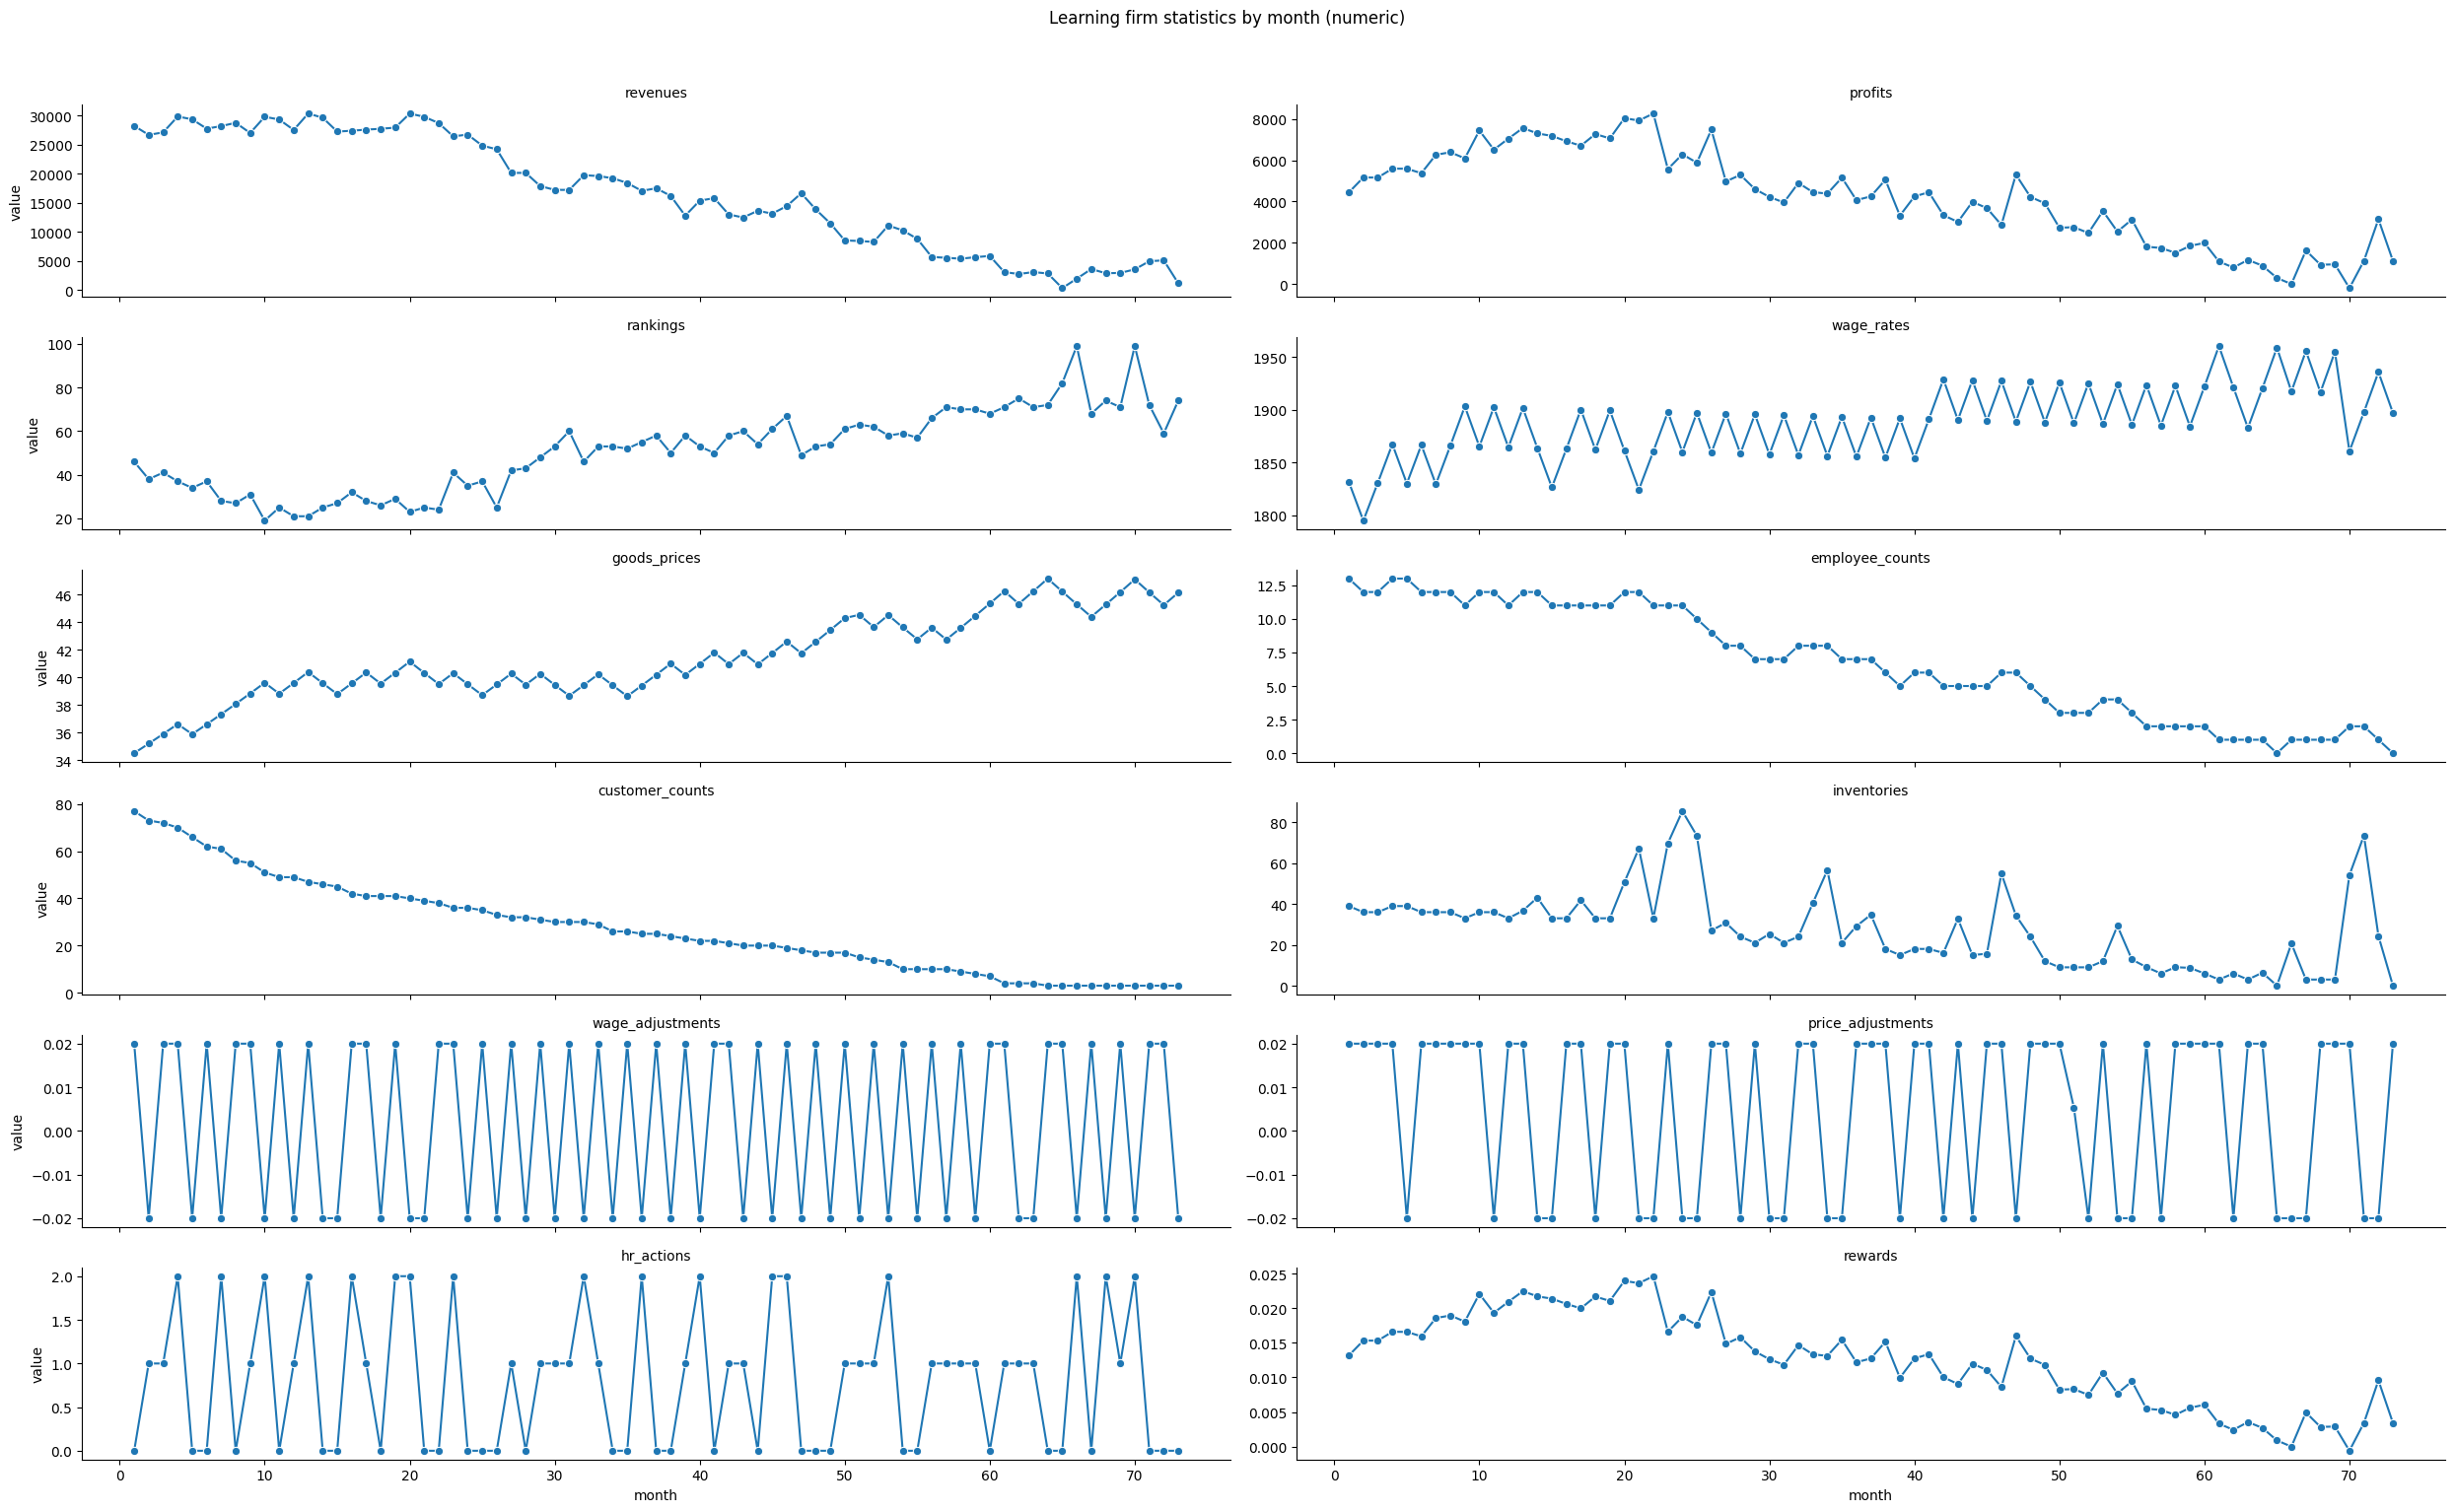

In [71]:
plot_stats(stats)

## Evaluating LSTM model (sb3_contrib)

In [7]:
%%time
stats, models = [], []

for _ in range(5):
    recurrent_ppo_sb = RecurrentPPO.load('results/model/sb3_contrib/4m')
    env = make_sb_env()
    stat, model = evaluate_lstm(env, recurrent_ppo_sb.predict, years=100, seed=0)
    stats.append(stat)
    models.append(model)

/Users/hieule/Library/Caches/pypoetry/virtualenvs/thesis-5oUIbZFM-py3.13/lib/python3.13/site-packages/gymnasium/spaces/box.py:235: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/Users/hieule/Library/Caches/pypoetry/virtualenvs/thesis-5oUIbZFM-py3.13/lib/python3.13/site-packages/gymnasium/spaces/box.py:305: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


Terminated! Went belly up
Firm survived for 39 years, making a total amount of 3597077.923076515 of profit, with total reward 7.959979128413484


KeyboardInterrupt: 

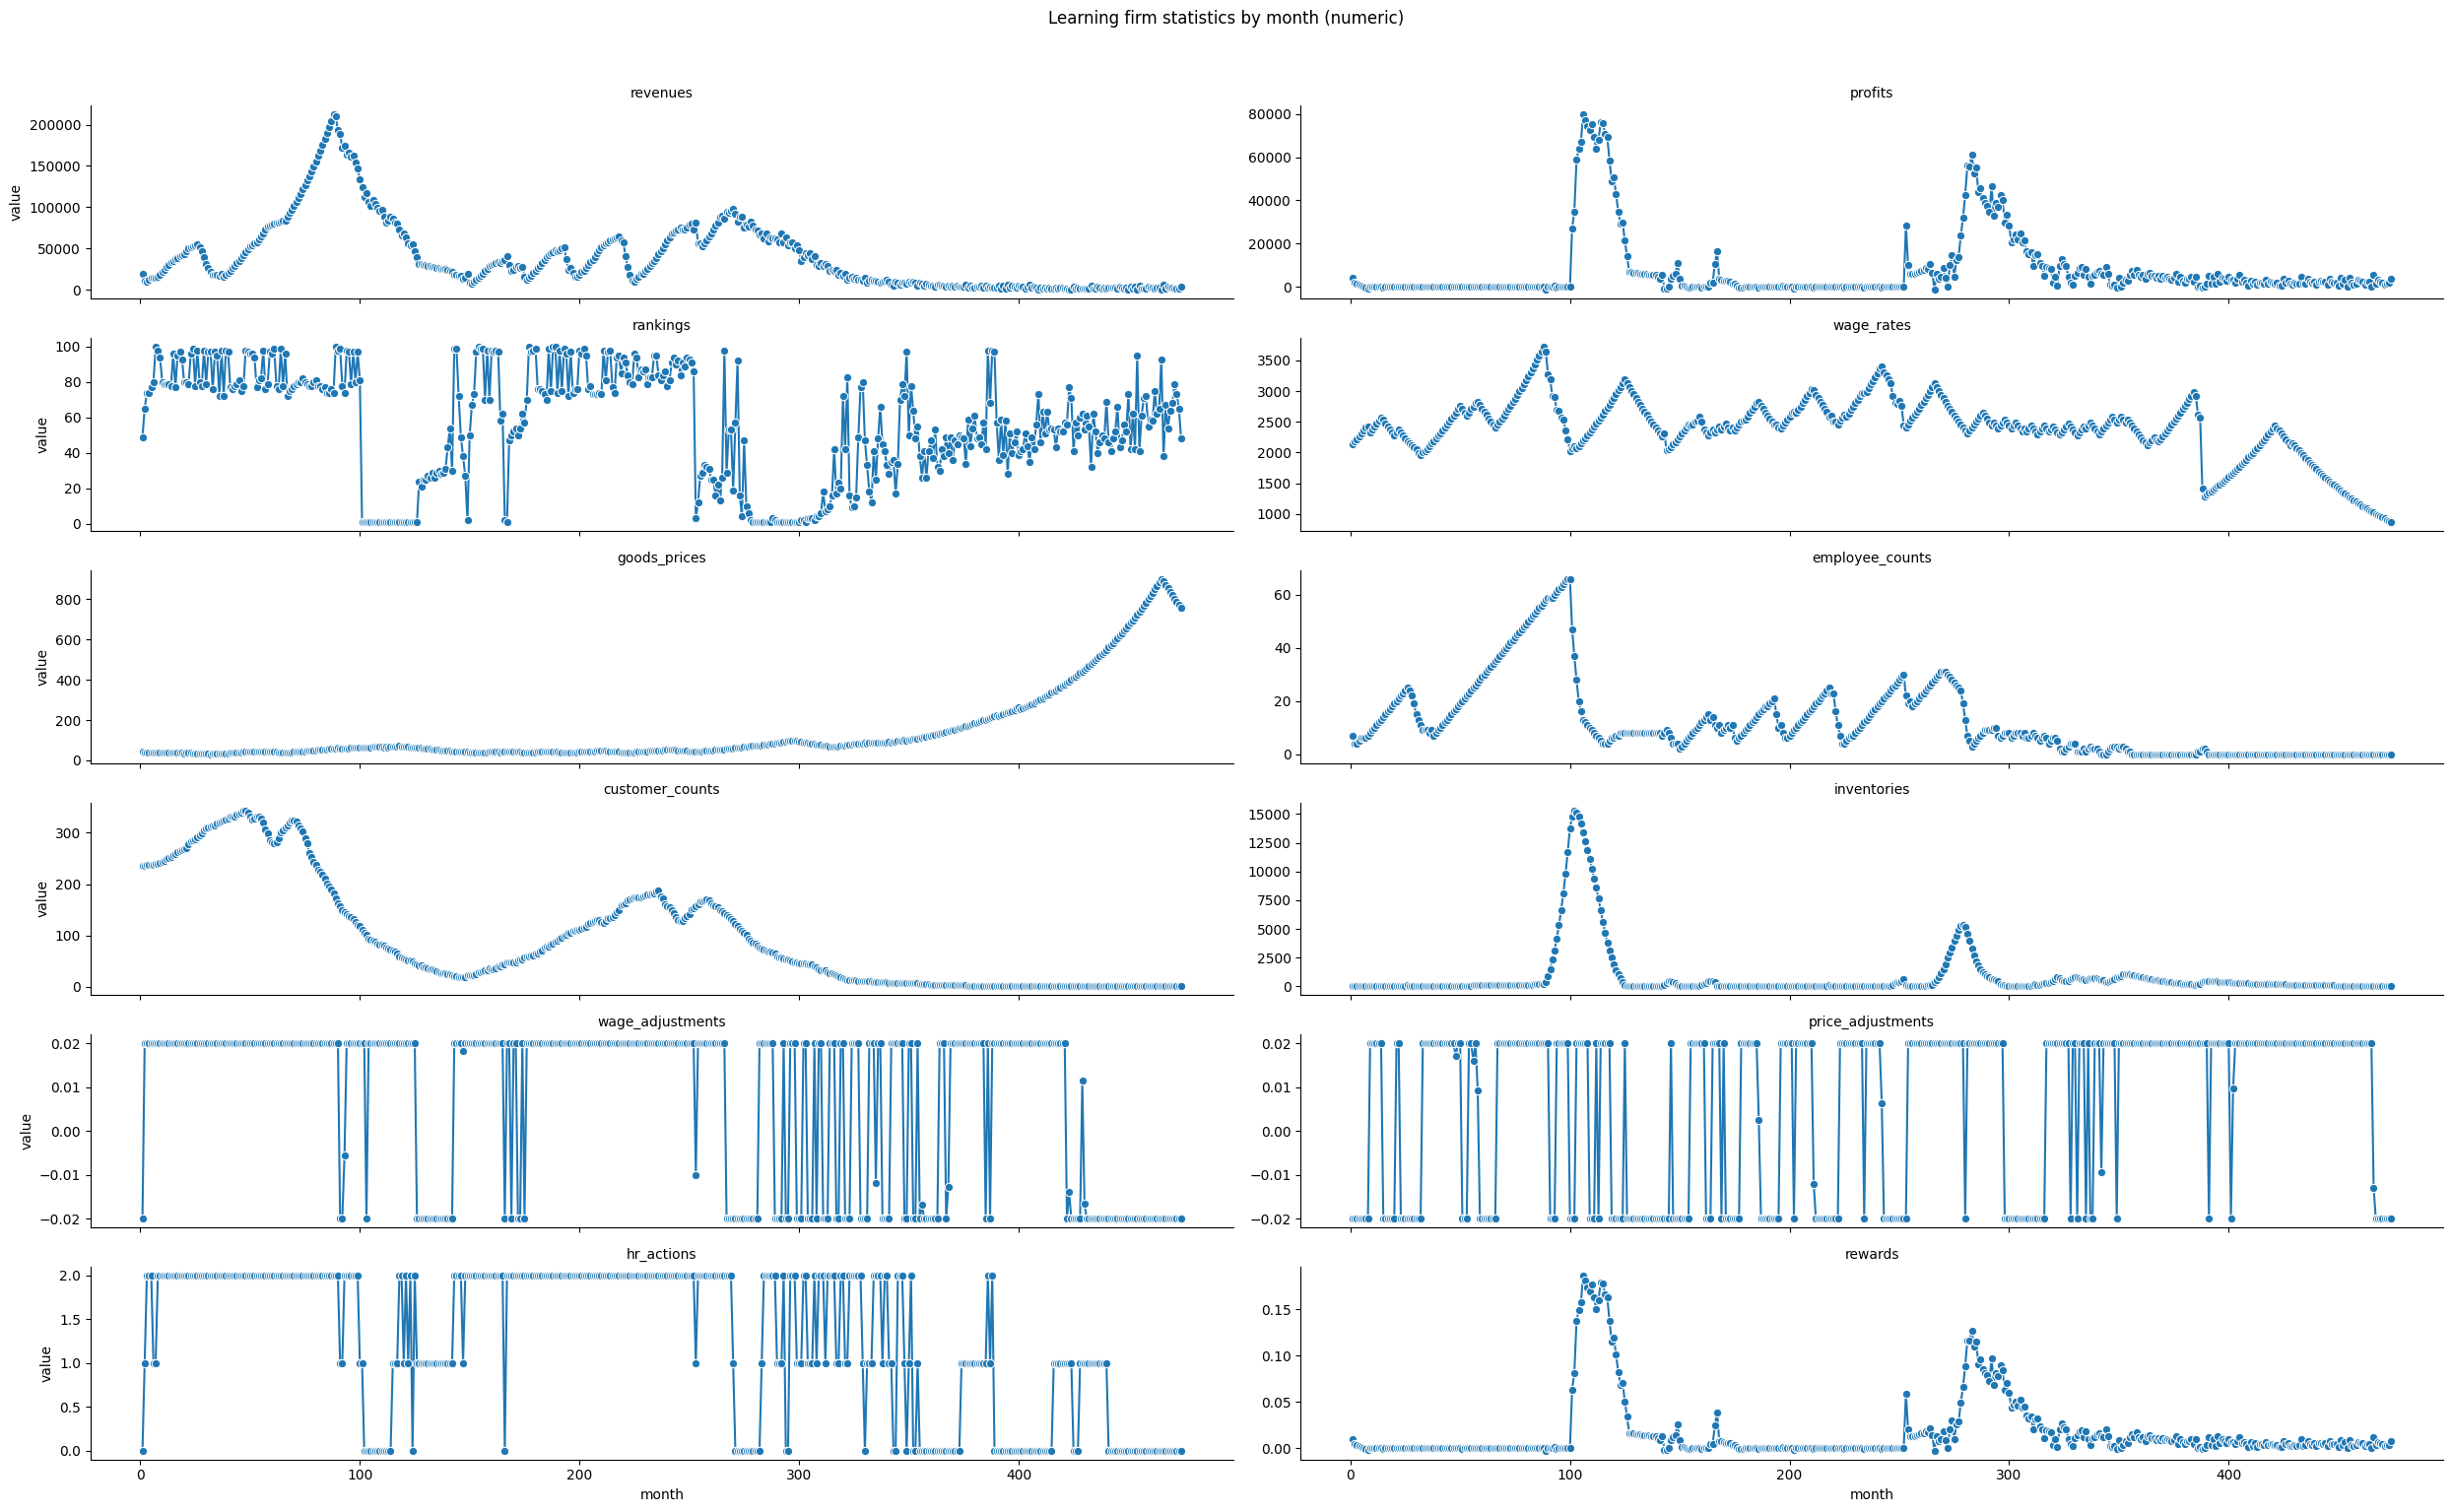

In [15]:
plot_stats(stats[0])

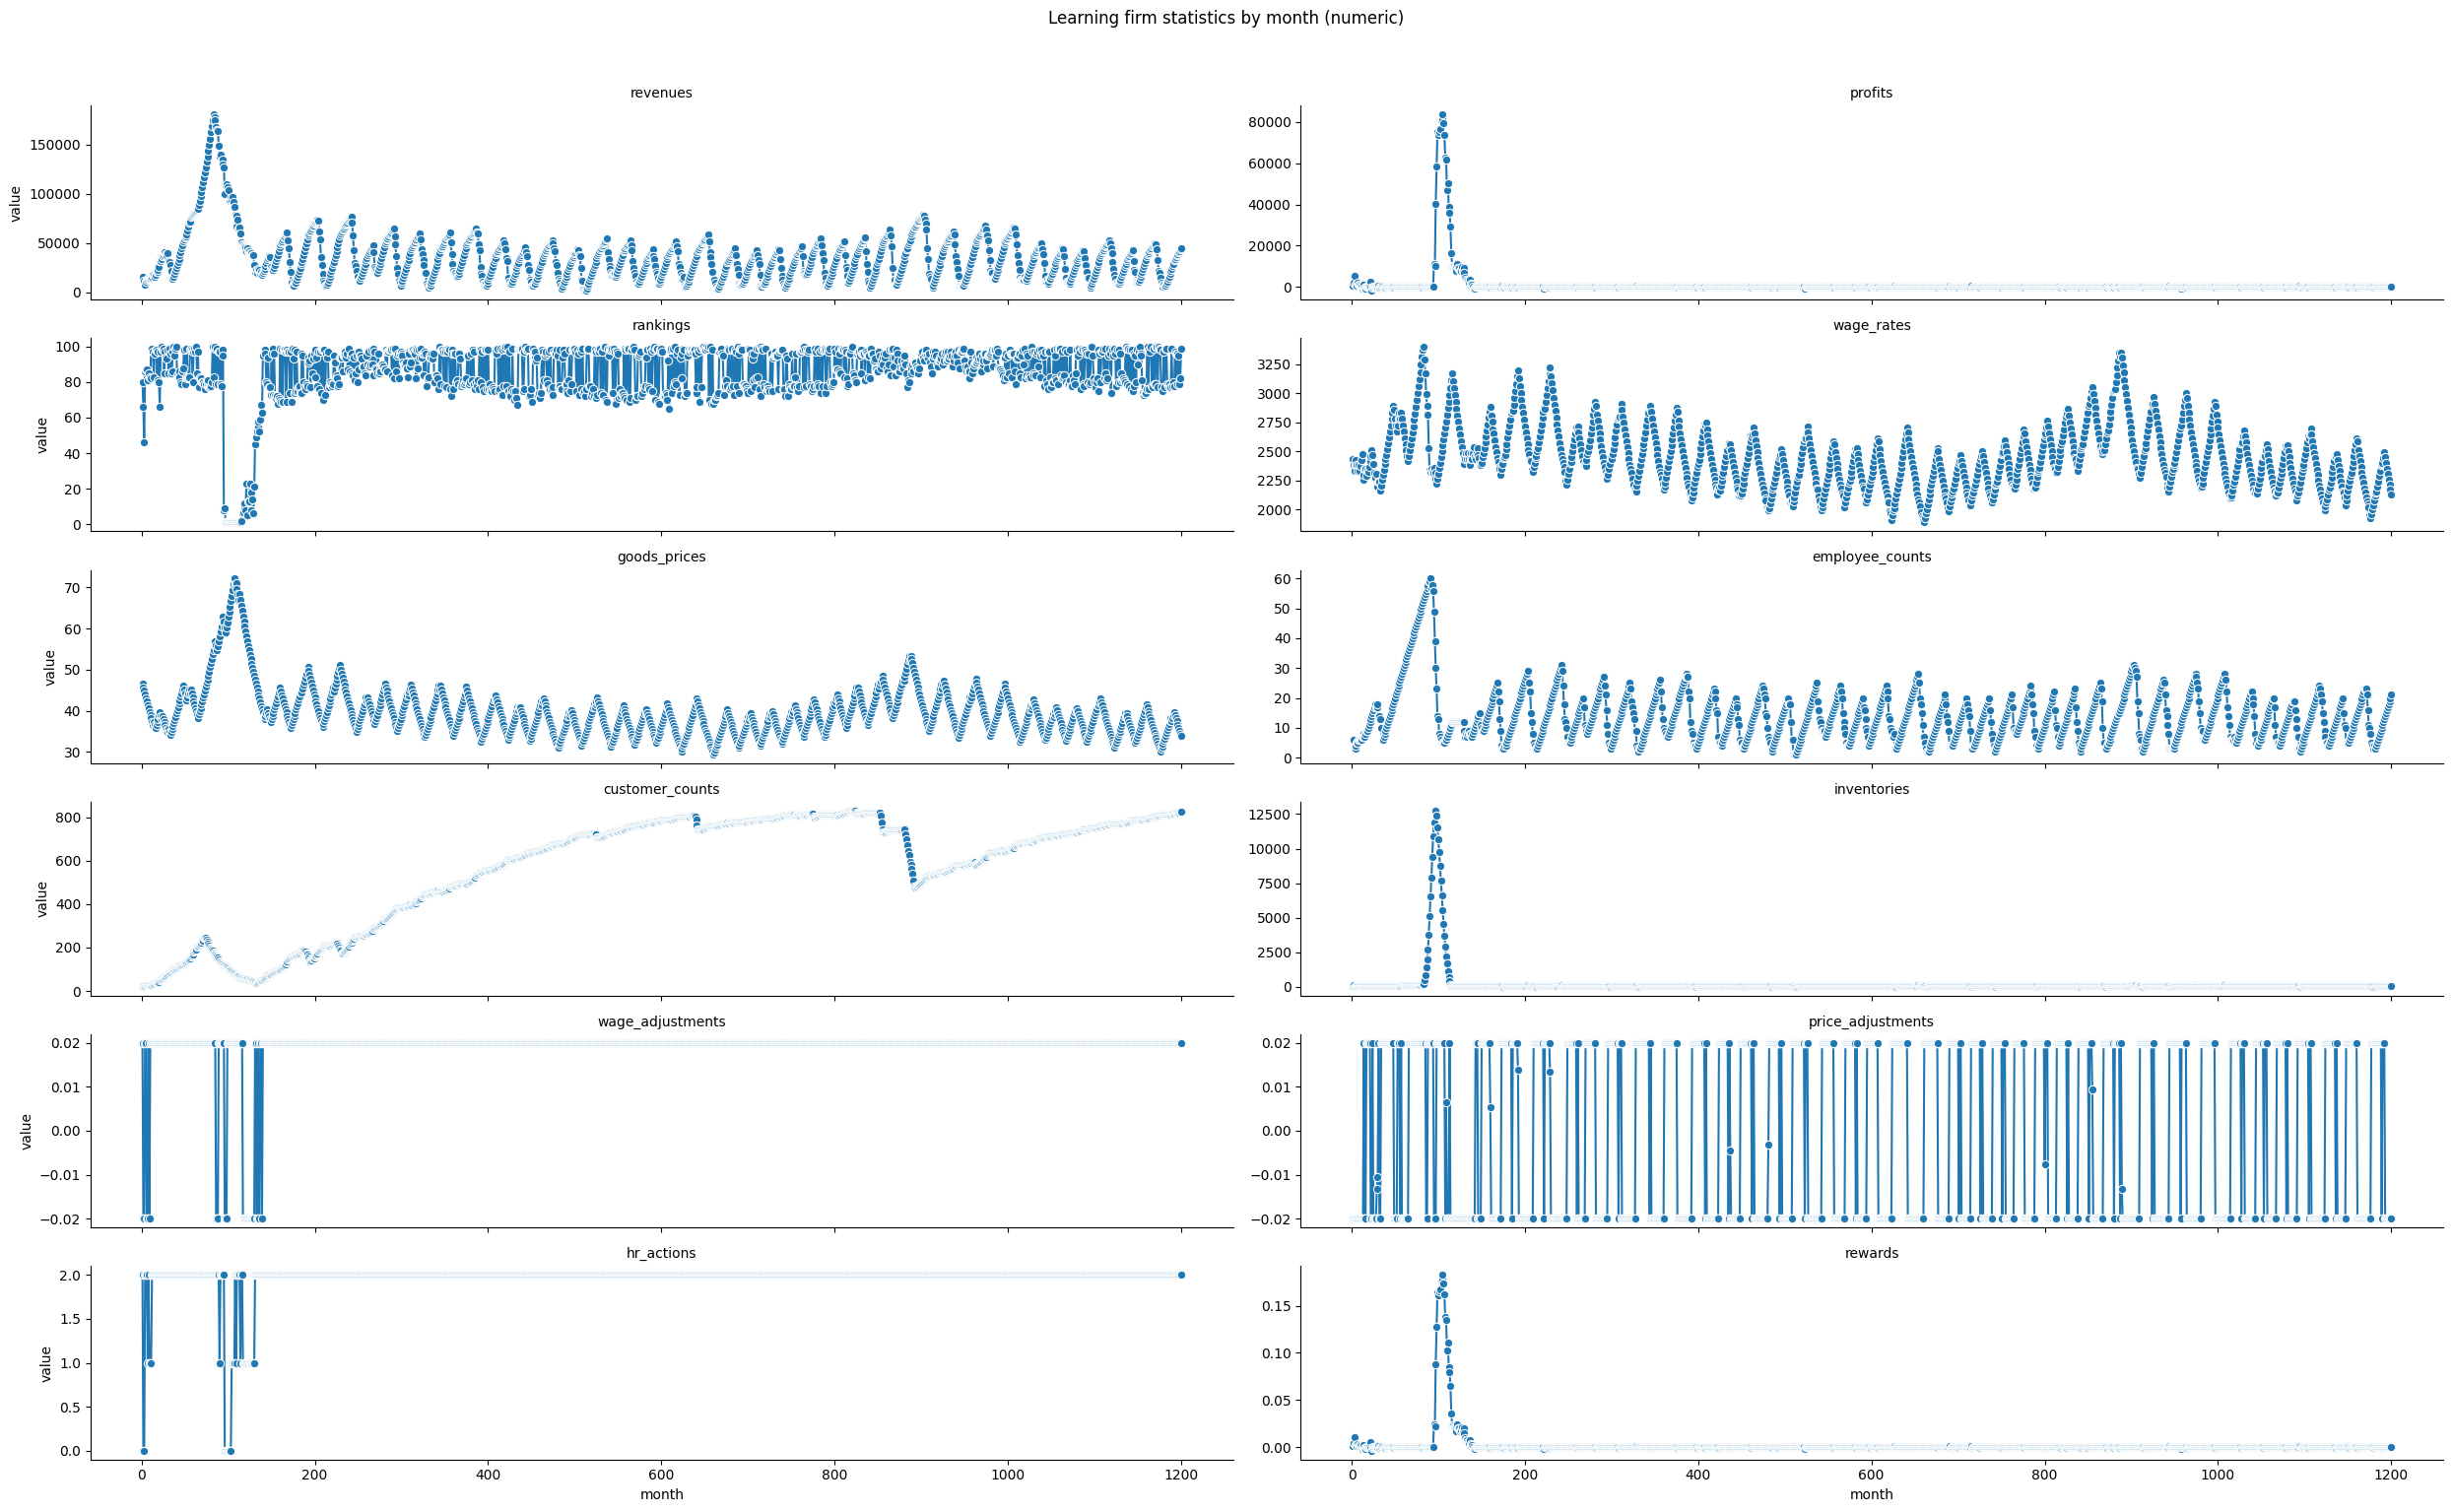

In [27]:
plot_stats(stats[4])

In [68]:
[e.reservation_wage for e in model.learning_firms[0].employees]

[1637.2561285628476,
 1635.24394918392,
 1653.4401241484884,
 1649.4692142891845,
 1630.4740996268426]

In [72]:
for i in range(1000):
    [e.find_employment() for e in model.learning_firms[0].employees]

In [70]:
model.learning_firms[0].employees[0].employer.wage_rate

1648.3824271614194

In [73]:
sum([len(f.employees) for f in model.firms])

1420

In [35]:
len([f for f in model.firms if f.open_position])

37

## Evaluating the custom multi-headed model

In [52]:
%%time
def evaluate_custom_lstm(model_path, years=100, seed=50):
    env = make_custom_env()()
    obs, info = env.reset(seed=seed)
    model = get_model_from_env(env)
    parameters = model.parameters
    learning_firm = model.learning_firms[0]
    stats = {
        # Firm stats
        'liquidity_buffers': [],
        'revenues': [],
        'profits': [],
        'rankings': [],
        'wage_rates': [],
        'goods_prices': [],
        'employee_counts': [],
        'customer_counts': [],
        'inventories': [],
        'last_month_demands': [],
        'months_since_hire_failure': [],
        # RL stats
        'wage_adjustments': [],
        'price_adjustments': [],
        'hr_actions': [],
        'rewards': []
    }
    
    def collect_stats(action, reward):
        stats['liquidity_buffers'].append(learning_firm.liquidity_buffer)
        stats['revenues'].append(learning_firm.last_month_revenue)
        stats['profits'].append(learning_firm.last_month_profit)
        stats['rankings'].append(get_ranking(learning_firm))
        stats['wage_rates'].append(learning_firm.wage_rate)
        stats['goods_prices'].append(learning_firm.goods_price)
        stats['employee_counts'].append(learning_firm.employee_count)
        stats['customer_counts'].append(learning_firm.customer_count)
        stats['inventories'].append(learning_firm.inventories)
        stats['last_month_demands'].append(learning_firm.last_month_demand)
        stats['months_since_hire_failure'].append(learning_firm.months_since_hire_failure)
        if 'hr_action' in action:
            stats['hr_actions'].append(int(np.clip(np.round(action['hr_action']), 0, 2)))
            stats['price_adjustments'].append(action['price_adjustment'])
            stats['wage_adjustments'].append(action['wage_adjustment'])
        else:
            stats['hr_actions'].append(int(np.clip(np.round(action[0]), 0, 2)))
            stats['price_adjustments'].append(action[1])
            stats['wage_adjustments'].append(action[2])
        stats['rewards'].append(reward)

    custom_lstm_agent = RecurrentPPOAgent(obs_dim=int(np.array(env.observation_space.shape).prod()))
    custom_lstm_agent.load_state_dict(torch.load(model_path, weights_only=True))
    custom_lstm_agent.eval()
    
    lstm_state = (torch.zeros(custom_lstm_agent.lstm.num_layers, 1, custom_lstm_agent.lstm.hidden_size),
                  torch.zeros(custom_lstm_agent.lstm.num_layers, 1, custom_lstm_agent.lstm.hidden_size))
    done = torch.zeros(1)
    # Run for n years
    for _ in range(years * 12):
        action, lstm_state = custom_lstm_agent.predict(torch.Tensor(np.array([obs])), lstm_state, done, deterministic=True)
        action = {
            'hr_action': int(action['hr_action']),
            'price_adjustment': float(action['price_adjustment']),
            'wage_adjustment': float(action['wage_adjustment'])
        }
        obs, reward, terminated, truncated, _ = env.step(action)
        collect_stats(action, reward)
        done = torch.Tensor(np.array([terminated]))
        if terminated:
            print('Terminated! Went belly up')
            break
        if truncated:
            print('Truncated! Unprofitable')
            break

    print(f'Firm survived for {len(stats['profits']) // 12} years, making a total amount of {sum(stats['profits'])} of profit, with total reward {sum(stats['rewards'])}')
    return stats, model

stats, models = [], []
for seed in range(22):
    print(f'Seed {seed}')
    stat, model = evaluate_custom_lstm('results/model/custom_lstm/2m_anneal.pt', years=100, seed=seed)
    stats.append(stat)
    models.append(model)

Seed 0
Terminated! Went belly up
Firm survived for 22 years, making a total amount of 12259942.601543285 of profit, with total reward 26.05947238853687
Seed 1
Terminated! Went belly up
Firm survived for 31 years, making a total amount of 11440199.298859462 of profit, with total reward 23.73938528842851
Seed 2
Terminated! Went belly up
Firm survived for 8 years, making a total amount of 449497.8660101479 of profit, with total reward 0.9525917113533947
Seed 3
Terminated! Went belly up
Firm survived for 24 years, making a total amount of 12707503.566913333 of profit, with total reward 27.237281842675355
Seed 4
Terminated! Went belly up
Firm survived for 0 years, making a total amount of 744.837094824003 of profit, with total reward 0.0016831741378556615
Seed 5
Terminated! Went belly up
Firm survived for 33 years, making a total amount of 13644704.662143067 of profit, with total reward 28.338307453695176
Seed 6
Terminated! Went belly up
Firm survived for 0 years, making a total amount of 3

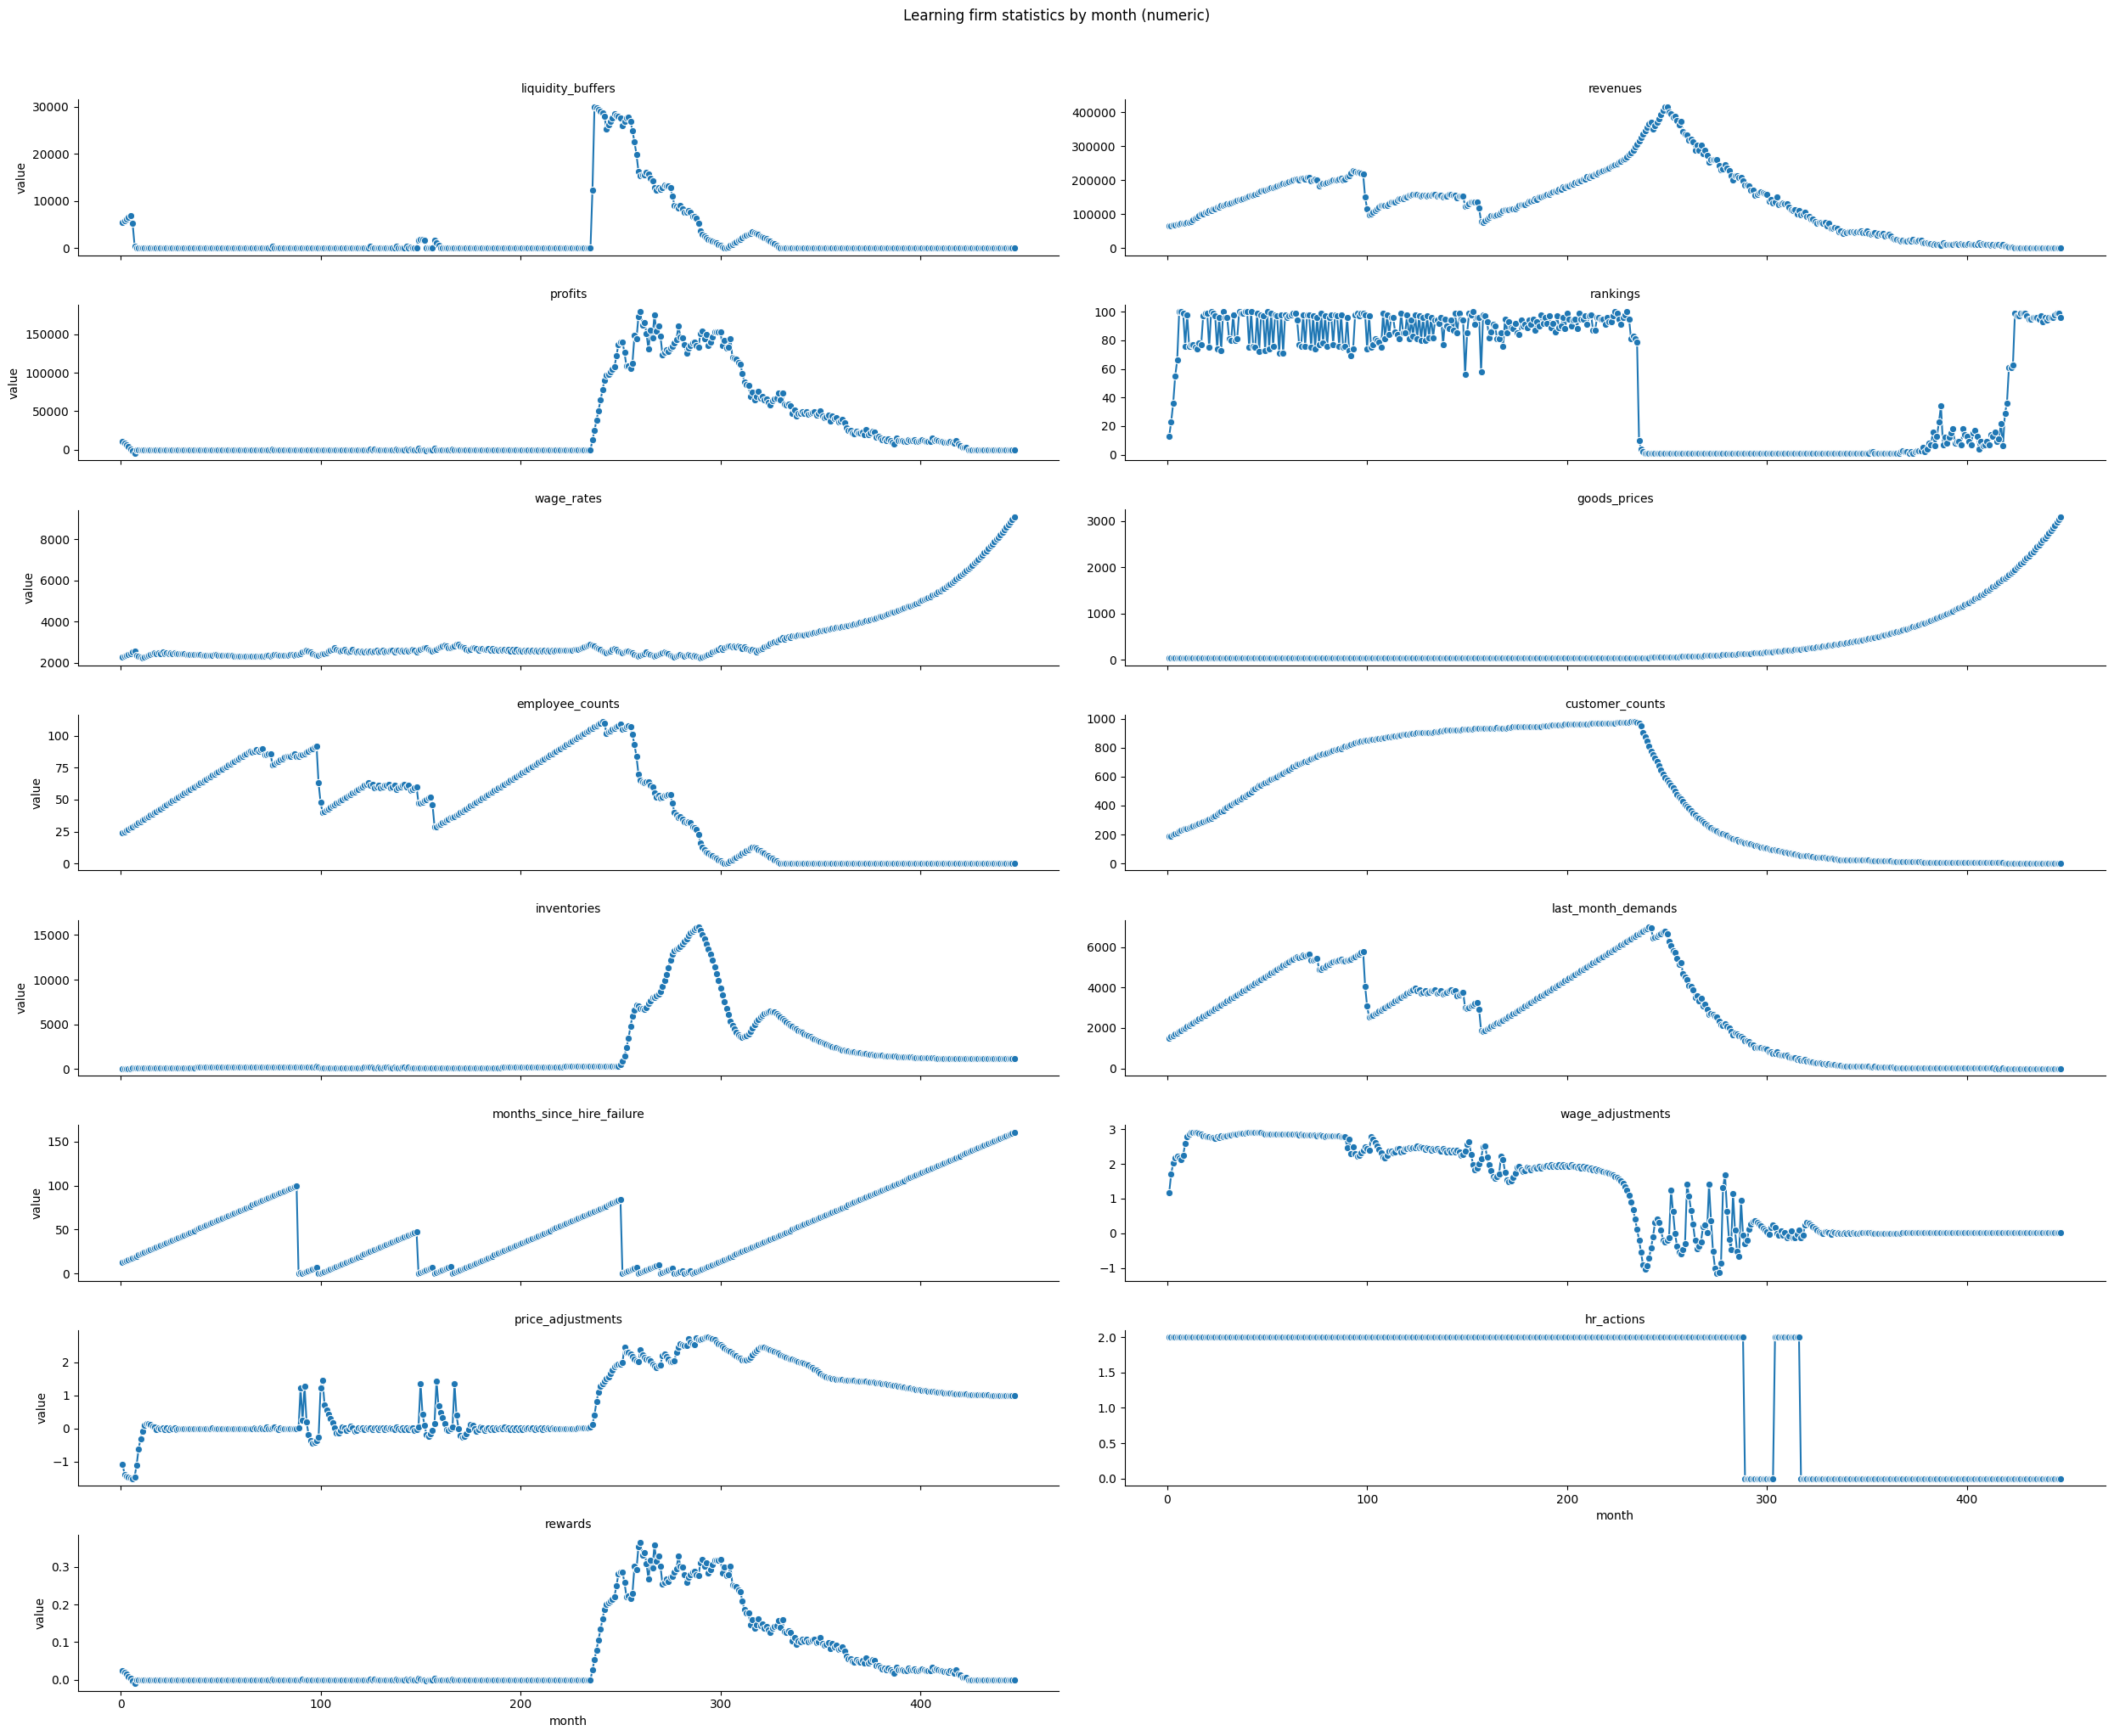

In [53]:
plot_stats(stats[19])

## Gaussian squashed 2m anneal

In [4]:
%%time
def evaluate_custom_lstm(model_path, years=100, seed=50):
    env = make_custom_env()()
    obs, info = env.reset(seed=seed)
    model = get_model_from_env(env)
    parameters = model.parameters
    learning_firm = model.learning_firms[0]
    stats = {
        # Firm stats
        'liquidity_buffers': [],
        'revenues': [],
        'profits': [],
        'rankings': [],
        'wage_rates': [],
        'goods_prices': [],
        'employee_counts': [],
        'customer_counts': [],
        'inventories': [],
        'last_month_demands': [],
        'months_since_hire_failure': [],
        # RL stats
        'wage_adjustments': [],
        'price_adjustments': [],
        'hr_actions': [],
        'rewards': []
    }
    
    def collect_stats(action, reward):
        stats['liquidity_buffers'].append(learning_firm.liquidity_buffer)
        stats['revenues'].append(learning_firm.last_month_revenue)
        stats['profits'].append(learning_firm.last_month_profit)
        stats['rankings'].append(get_ranking(learning_firm))
        stats['wage_rates'].append(learning_firm.wage_rate)
        stats['goods_prices'].append(learning_firm.goods_price)
        stats['employee_counts'].append(learning_firm.employee_count)
        stats['customer_counts'].append(learning_firm.customer_count)
        stats['inventories'].append(learning_firm.inventories)
        stats['last_month_demands'].append(learning_firm.last_month_demand)
        stats['months_since_hire_failure'].append(learning_firm.months_since_hire_failure)
        if 'hr_action' in action:
            stats['hr_actions'].append(int(np.clip(np.round(action['hr_action']), 0, 2)))
            stats['price_adjustments'].append(action['price_adjustment'])
            stats['wage_adjustments'].append(action['wage_adjustment'])
        else:
            stats['hr_actions'].append(int(np.clip(np.round(action[0]), 0, 2)))
            stats['price_adjustments'].append(action[1])
            stats['wage_adjustments'].append(action[2])
        stats['rewards'].append(reward)

    custom_lstm_agent = SquashedLSTMAgent(obs_dim=int(np.array(env.observation_space.shape).prod()))
    custom_lstm_agent.load_state_dict(torch.load(model_path, weights_only=True))
    custom_lstm_agent.eval()
    
    lstm_state = (torch.zeros(custom_lstm_agent.lstm.num_layers, 1, custom_lstm_agent.lstm.hidden_size),
                  torch.zeros(custom_lstm_agent.lstm.num_layers, 1, custom_lstm_agent.lstm.hidden_size))
    done = torch.zeros(1)
    # Run for n years
    for _ in range(years * 12):
        action, lstm_state = custom_lstm_agent.predict(torch.Tensor(np.array([obs])), lstm_state, done, deterministic=True)
        action = {
            'hr_action': int(action['hr_action']),
            'price_adjustment': float(action['price_adjustment']),
            'wage_adjustment': float(action['wage_adjustment'])
        }
        obs, reward, terminated, truncated, _ = env.step(action)
        collect_stats(action, reward)
        done = torch.Tensor(np.array([terminated]))
        if terminated:
            print('Terminated! Went belly up')
            break
        if truncated:
            print('Truncated! Unprofitable')
            break

    print(f'Firm survived for {len(stats['profits']) // 12} years, making a total amount of {sum(stats['profits'])} of profit, with total reward {sum(stats['rewards'])}')
    return stats, model

stats, models = [], []
for seed in range(22):
    print(f'Seed {seed}')
    stat, model = evaluate_custom_lstm('results/model/custom_lstm_bounded/2m_anneal.pt', years=100, seed=seed)
    stats.append(stat)
    models.append(model)

Seed 0
Terminated! Went belly up
Firm survived for 24 years, making a total amount of 9339303.863044508 of profit, with total reward 21.33015750678608
Seed 1
Terminated! Went belly up
Firm survived for 30 years, making a total amount of 8130941.424293211 of profit, with total reward 17.402810530841275
Seed 2
Terminated! Went belly up
Firm survived for 27 years, making a total amount of 9879308.396577794 of profit, with total reward 21.616530028903735
Seed 3
Terminated! Went belly up
Firm survived for 47 years, making a total amount of 11058488.050176743 of profit, with total reward 23.532002489660357
Seed 4
Terminated! Went belly up
Firm survived for 1 years, making a total amount of 1692.9063752167353 of profit, with total reward 0.0038315120552448265
Seed 5
Terminated! Went belly up
Firm survived for 19 years, making a total amount of 8571884.66714126 of profit, with total reward 18.80312681423938
Seed 6
Terminated! Went belly up
Firm survived for 0 years, making a total amount of 35

In [6]:
stats[2]['employee_counts'][0]

6

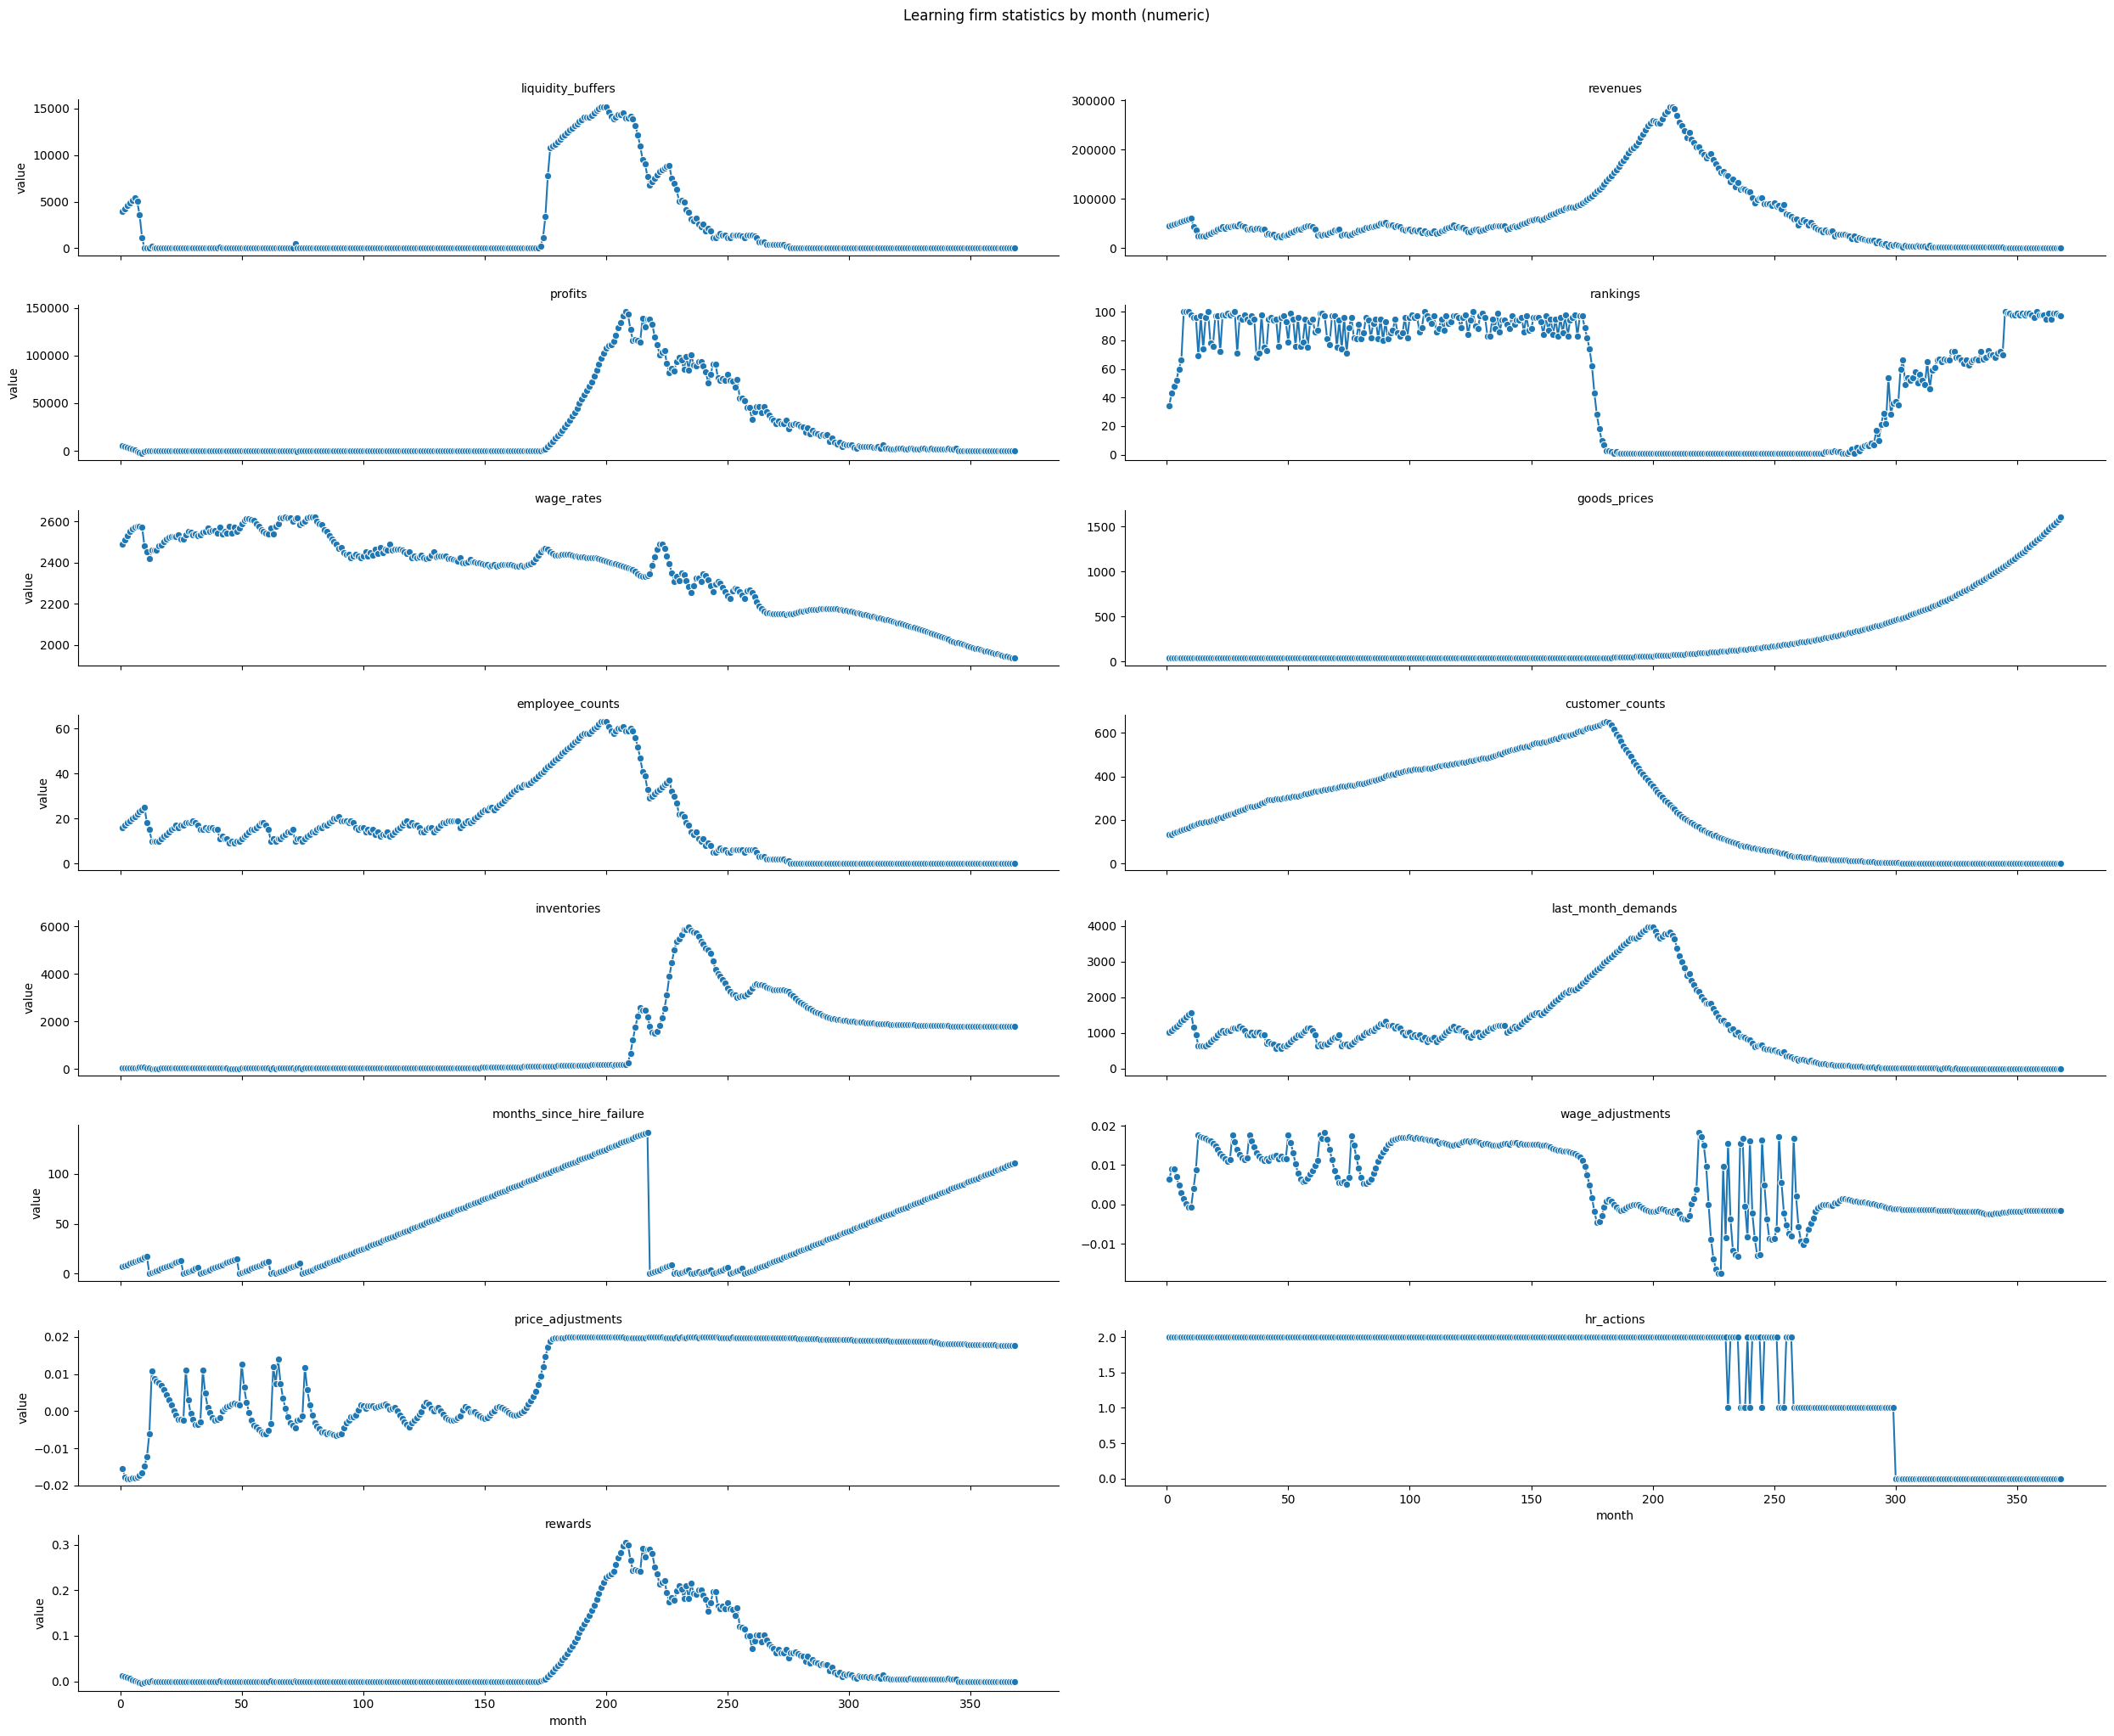

In [8]:
plot_stats(stats[1])

## 4m anneal

In [9]:
%%time
def evaluate_custom_lstm(model_path, years=100, seed=50):
    env = make_custom_env()()
    obs, info = env.reset(seed=seed)
    model = get_model_from_env(env)
    parameters = model.parameters
    learning_firm = model.learning_firms[0]
    stats = {
        # Firm stats
        'liquidity_buffers': [],
        'revenues': [],
        'profits': [],
        'rankings': [],
        'wage_rates': [],
        'goods_prices': [],
        'employee_counts': [],
        'customer_counts': [],
        'inventories': [],
        'last_month_demands': [],
        'months_since_hire_failure': [],
        # RL stats
        'wage_adjustments': [],
        'price_adjustments': [],
        'hr_actions': [],
        'rewards': []
    }
    
    def collect_stats(action, reward):
        stats['liquidity_buffers'].append(learning_firm.liquidity_buffer)
        stats['revenues'].append(learning_firm.last_month_revenue)
        stats['profits'].append(learning_firm.last_month_profit)
        stats['rankings'].append(get_ranking(learning_firm))
        stats['wage_rates'].append(learning_firm.wage_rate)
        stats['goods_prices'].append(learning_firm.goods_price)
        stats['employee_counts'].append(learning_firm.employee_count)
        stats['customer_counts'].append(learning_firm.customer_count)
        stats['inventories'].append(learning_firm.inventories)
        stats['last_month_demands'].append(learning_firm.last_month_demand)
        stats['months_since_hire_failure'].append(learning_firm.months_since_hire_failure)
        if 'hr_action' in action:
            stats['hr_actions'].append(int(np.clip(np.round(action['hr_action']), 0, 2)))
            stats['price_adjustments'].append(action['price_adjustment'])
            stats['wage_adjustments'].append(action['wage_adjustment'])
        else:
            stats['hr_actions'].append(int(np.clip(np.round(action[0]), 0, 2)))
            stats['price_adjustments'].append(action[1])
            stats['wage_adjustments'].append(action[2])
        stats['rewards'].append(reward)

    custom_lstm_agent = SquashedLSTMAgent(obs_dim=int(np.array(env.observation_space.shape).prod()))
    custom_lstm_agent.load_state_dict(torch.load(model_path, weights_only=True))
    custom_lstm_agent.eval()
    
    lstm_state = (torch.zeros(custom_lstm_agent.lstm.num_layers, 1, custom_lstm_agent.lstm.hidden_size),
                  torch.zeros(custom_lstm_agent.lstm.num_layers, 1, custom_lstm_agent.lstm.hidden_size))
    done = torch.zeros(1)
    # Run for n years
    for _ in range(years * 12):
        action, lstm_state = custom_lstm_agent.predict(torch.Tensor(np.array([obs])), lstm_state, done, deterministic=True)
        action = {
            'hr_action': int(action['hr_action']),
            'price_adjustment': float(action['price_adjustment']),
            'wage_adjustment': float(action['wage_adjustment'])
        }
        obs, reward, terminated, truncated, _ = env.step(action)
        collect_stats(action, reward)
        done = torch.Tensor(np.array([terminated]))
        if terminated:
            print('Terminated! Went belly up')
            break
        if truncated:
            print('Truncated! Unprofitable')
            break

    print(f'Firm survived for {len(stats['profits']) // 12} years, making a total amount of {sum(stats['profits'])} of profit, with total reward {sum(stats['rewards'])}')
    return stats, model

stats, models = [], []
for seed in range(22):
    print(f'Seed {seed}')
    stat, model = evaluate_custom_lstm('results/model/custom_lstm_bounded/4m_anneal.pt', years=100, seed=seed)
    stats.append(stat)
    models.append(model)

Seed 0
Terminated! Went belly up
Firm survived for 25 years, making a total amount of 12128413.539991729 of profit, with total reward 26.050223144118057
Seed 1
Terminated! Went belly up
Firm survived for 35 years, making a total amount of 12641044.670769261 of profit, with total reward 26.958739171145282
Seed 2
Terminated! Went belly up
Firm survived for 32 years, making a total amount of 12530860.169766653 of profit, with total reward 26.90333931330265
Seed 3
Terminated! Went belly up
Firm survived for 28 years, making a total amount of 11606393.999758279 of profit, with total reward 24.908141409466758
Seed 4
Terminated! Went belly up
Firm survived for 1 years, making a total amount of 30458.695487888683 of profit, with total reward 0.06913039692963868
Seed 5
Terminated! Went belly up
Firm survived for 31 years, making a total amount of 10891906.08649922 of profit, with total reward 22.946608687219314
Seed 6
Terminated! Went belly up
Firm survived for 0 years, making a total amount of

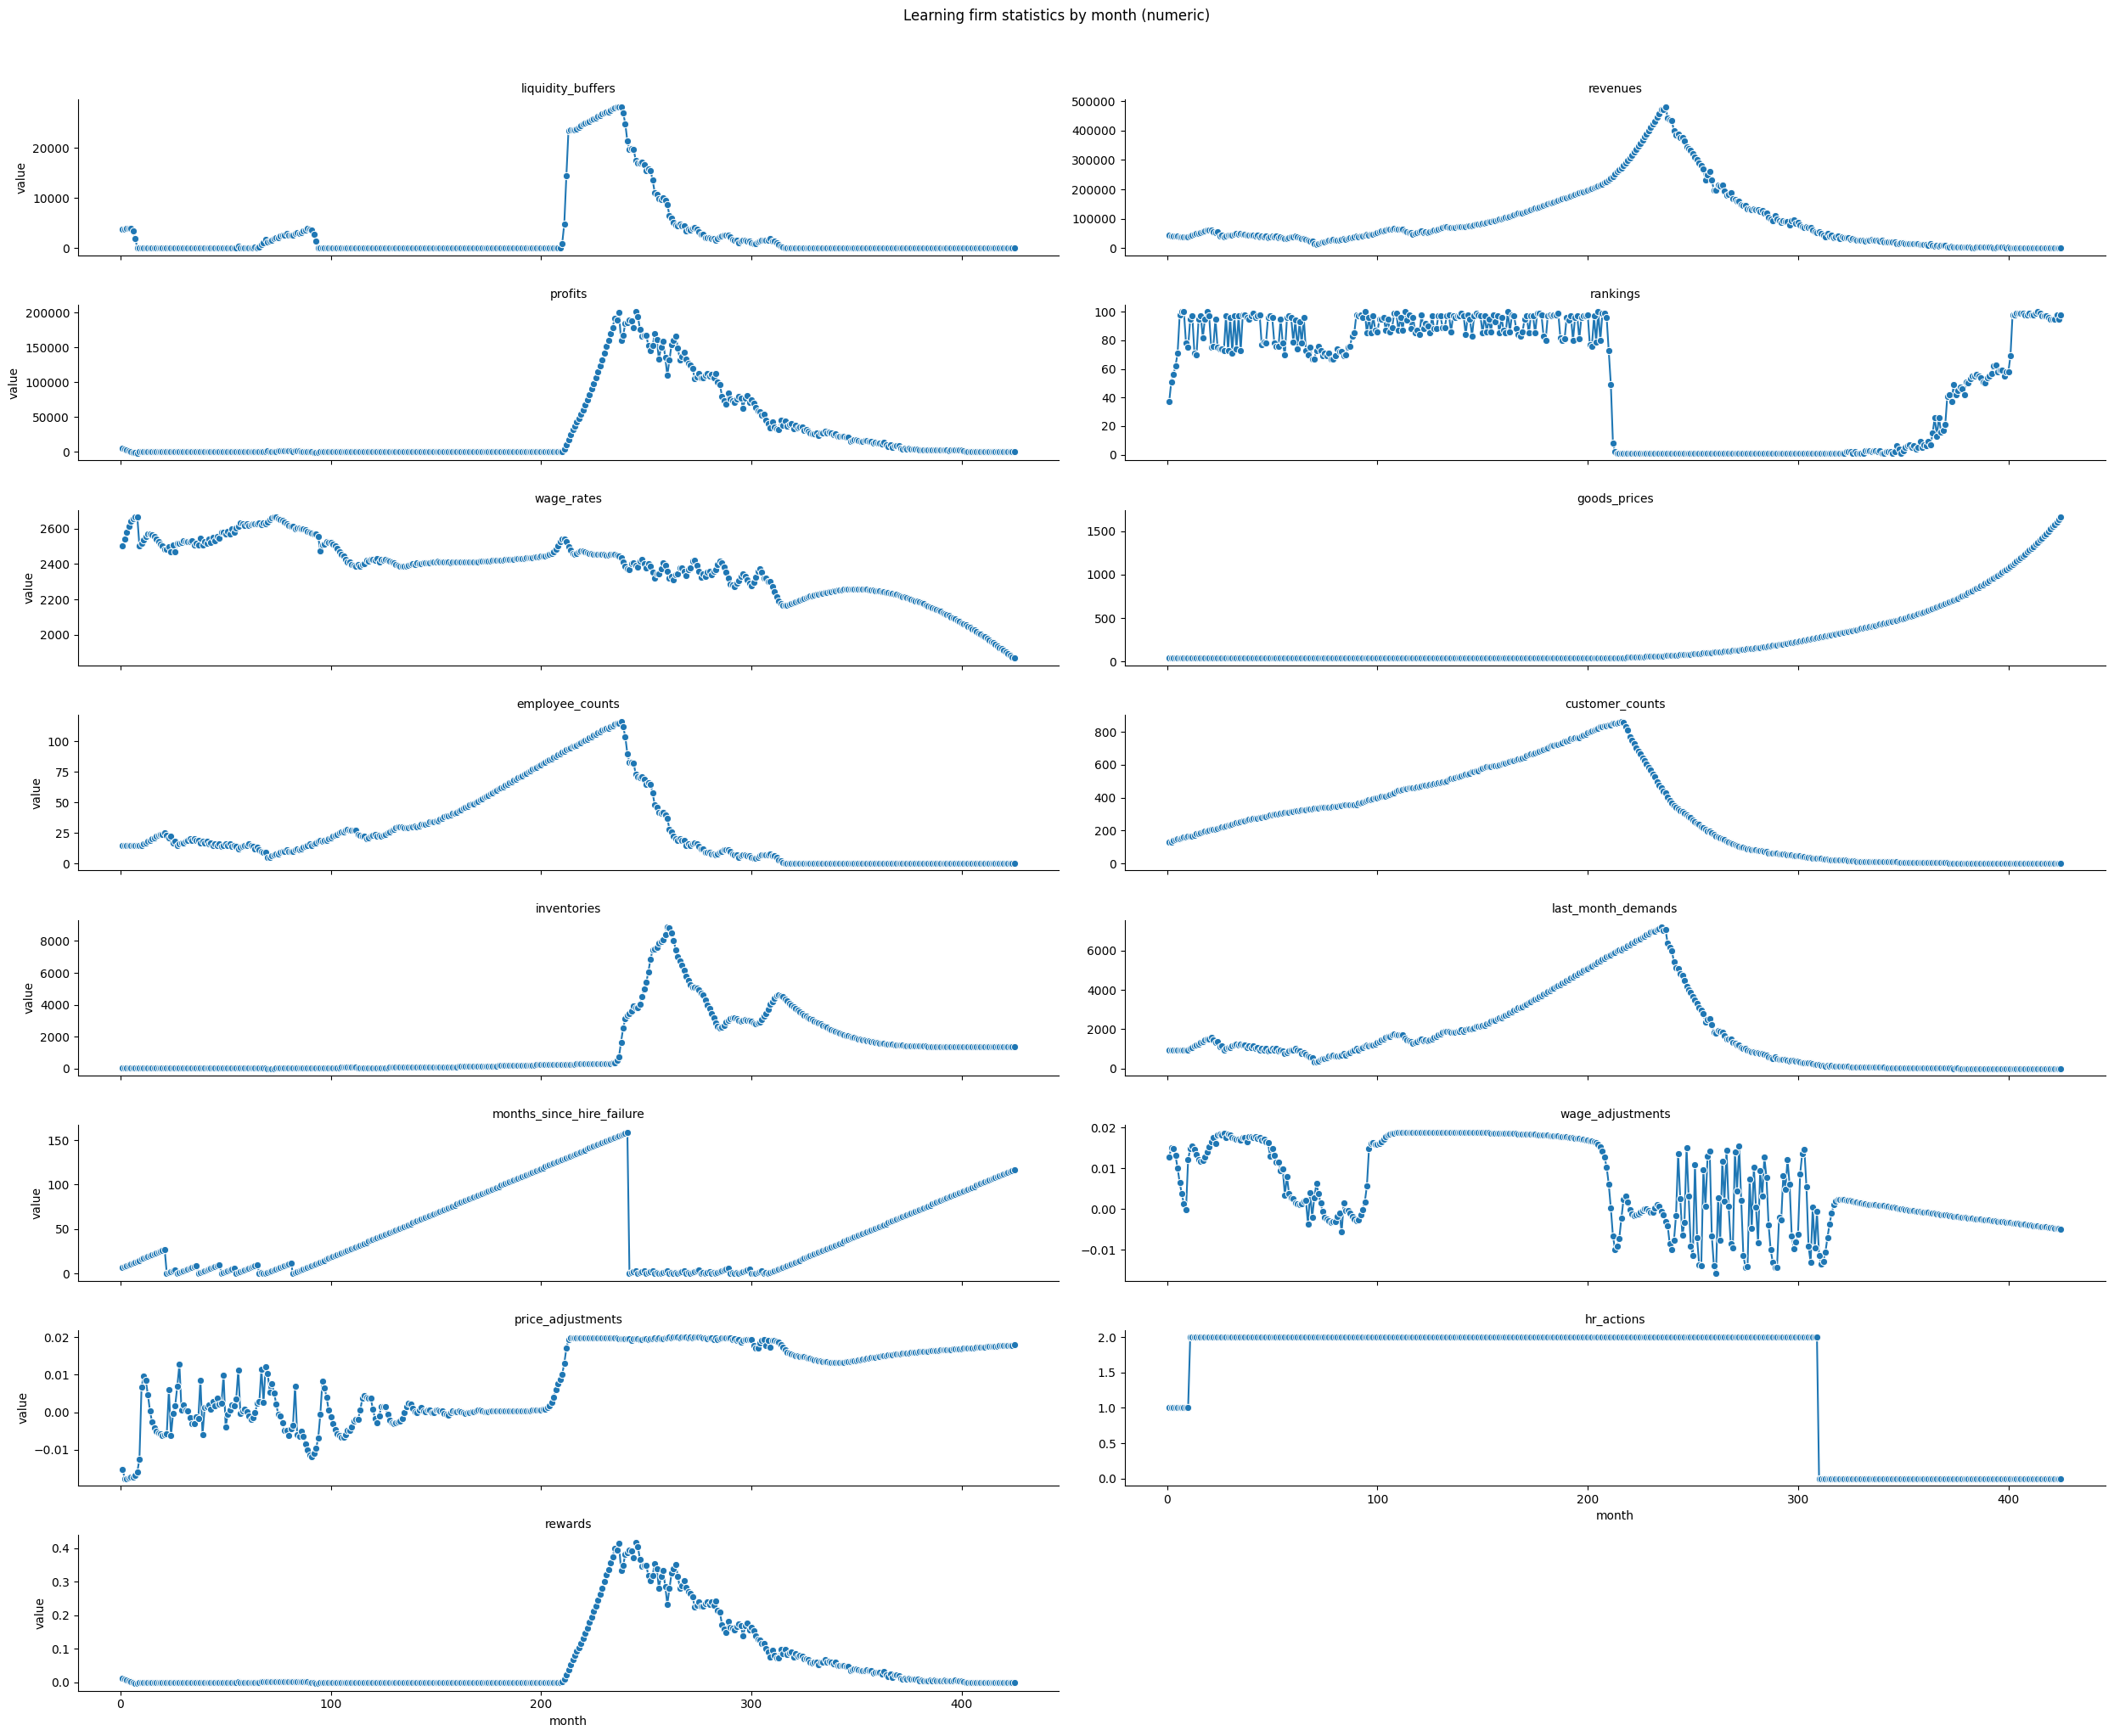

In [10]:
plot_stats(stats[1])

## Survival bonus

In [11]:
%%time
def evaluate_custom_lstm(model_path, years=100, seed=50):
    env = make_custom_env()()
    obs, info = env.reset(seed=seed)
    model = get_model_from_env(env)
    parameters = model.parameters
    learning_firm = model.learning_firms[0]
    stats = {
        # Firm stats
        'liquidity_buffers': [],
        'revenues': [],
        'profits': [],
        'rankings': [],
        'wage_rates': [],
        'goods_prices': [],
        'employee_counts': [],
        'customer_counts': [],
        'inventories': [],
        'last_month_demands': [],
        'months_since_hire_failure': [],
        # RL stats
        'wage_adjustments': [],
        'price_adjustments': [],
        'hr_actions': [],
        'rewards': []
    }
    
    def collect_stats(action, reward):
        stats['liquidity_buffers'].append(learning_firm.liquidity_buffer)
        stats['revenues'].append(learning_firm.last_month_revenue)
        stats['profits'].append(learning_firm.last_month_profit)
        stats['rankings'].append(get_ranking(learning_firm))
        stats['wage_rates'].append(learning_firm.wage_rate)
        stats['goods_prices'].append(learning_firm.goods_price)
        stats['employee_counts'].append(learning_firm.employee_count)
        stats['customer_counts'].append(learning_firm.customer_count)
        stats['inventories'].append(learning_firm.inventories)
        stats['last_month_demands'].append(learning_firm.last_month_demand)
        stats['months_since_hire_failure'].append(learning_firm.months_since_hire_failure)
        if 'hr_action' in action:
            stats['hr_actions'].append(int(np.clip(np.round(action['hr_action']), 0, 2)))
            stats['price_adjustments'].append(action['price_adjustment'])
            stats['wage_adjustments'].append(action['wage_adjustment'])
        else:
            stats['hr_actions'].append(int(np.clip(np.round(action[0]), 0, 2)))
            stats['price_adjustments'].append(action[1])
            stats['wage_adjustments'].append(action[2])
        stats['rewards'].append(reward)

    custom_lstm_agent = SquashedLSTMAgent(obs_dim=int(np.array(env.observation_space.shape).prod()))
    custom_lstm_agent.load_state_dict(torch.load(model_path, weights_only=True))
    custom_lstm_agent.eval()
    
    lstm_state = (torch.zeros(custom_lstm_agent.lstm.num_layers, 1, custom_lstm_agent.lstm.hidden_size),
                  torch.zeros(custom_lstm_agent.lstm.num_layers, 1, custom_lstm_agent.lstm.hidden_size))
    done = torch.zeros(1)
    # Run for n years
    for _ in range(years * 12):
        action, lstm_state = custom_lstm_agent.predict(torch.Tensor(np.array([obs])), lstm_state, done, deterministic=True)
        action = {
            'hr_action': int(action['hr_action']),
            'price_adjustment': float(action['price_adjustment']),
            'wage_adjustment': float(action['wage_adjustment'])
        }
        obs, reward, terminated, truncated, _ = env.step(action)
        collect_stats(action, reward)
        done = torch.Tensor(np.array([terminated]))
        if terminated:
            print('Terminated! Went belly up')
            break
        if truncated:
            print('Truncated! Unprofitable')
            break

    print(f'Firm survived for {len(stats['profits']) // 12} years, making a total amount of {sum(stats['profits'])} of profit, with total reward {sum(stats['rewards'])}')
    return stats, model

stats, models = [], []
for seed in range(22):
    print(f'Seed {seed}')
    stat, model = evaluate_custom_lstm('results/model/lstm_survival_bonus/2m_anneal.pt', years=100, seed=seed)
    stats.append(stat)
    models.append(model)

Seed 0
Terminated! Went belly up
Firm survived for 20 years, making a total amount of 1707526.9342581439 of profit, with total reward 3.986782948962688
Seed 1
Terminated! Went belly up
Firm survived for 63 years, making a total amount of 6850208.771226077 of profit, with total reward 15.174815904141434
Seed 2
Terminated! Went belly up
Firm survived for 4 years, making a total amount of 129290.91230073222 of profit, with total reward 0.2723228790954452
Seed 3
Firm survived for 100 years, making a total amount of 35336239.9845422 of profit, with total reward 75.2846183619659
Seed 4
Terminated! Went belly up
Firm survived for 0 years, making a total amount of 6318.946925923858 of profit, with total reward 0.014308598335038246
Seed 5
Terminated! Went belly up
Firm survived for 1 years, making a total amount of 74066.52929636253 of profit, with total reward 0.15808124991579633
Seed 6
Terminated! Went belly up
Firm survived for 0 years, making a total amount of 3635.4581918544095 of profit, 

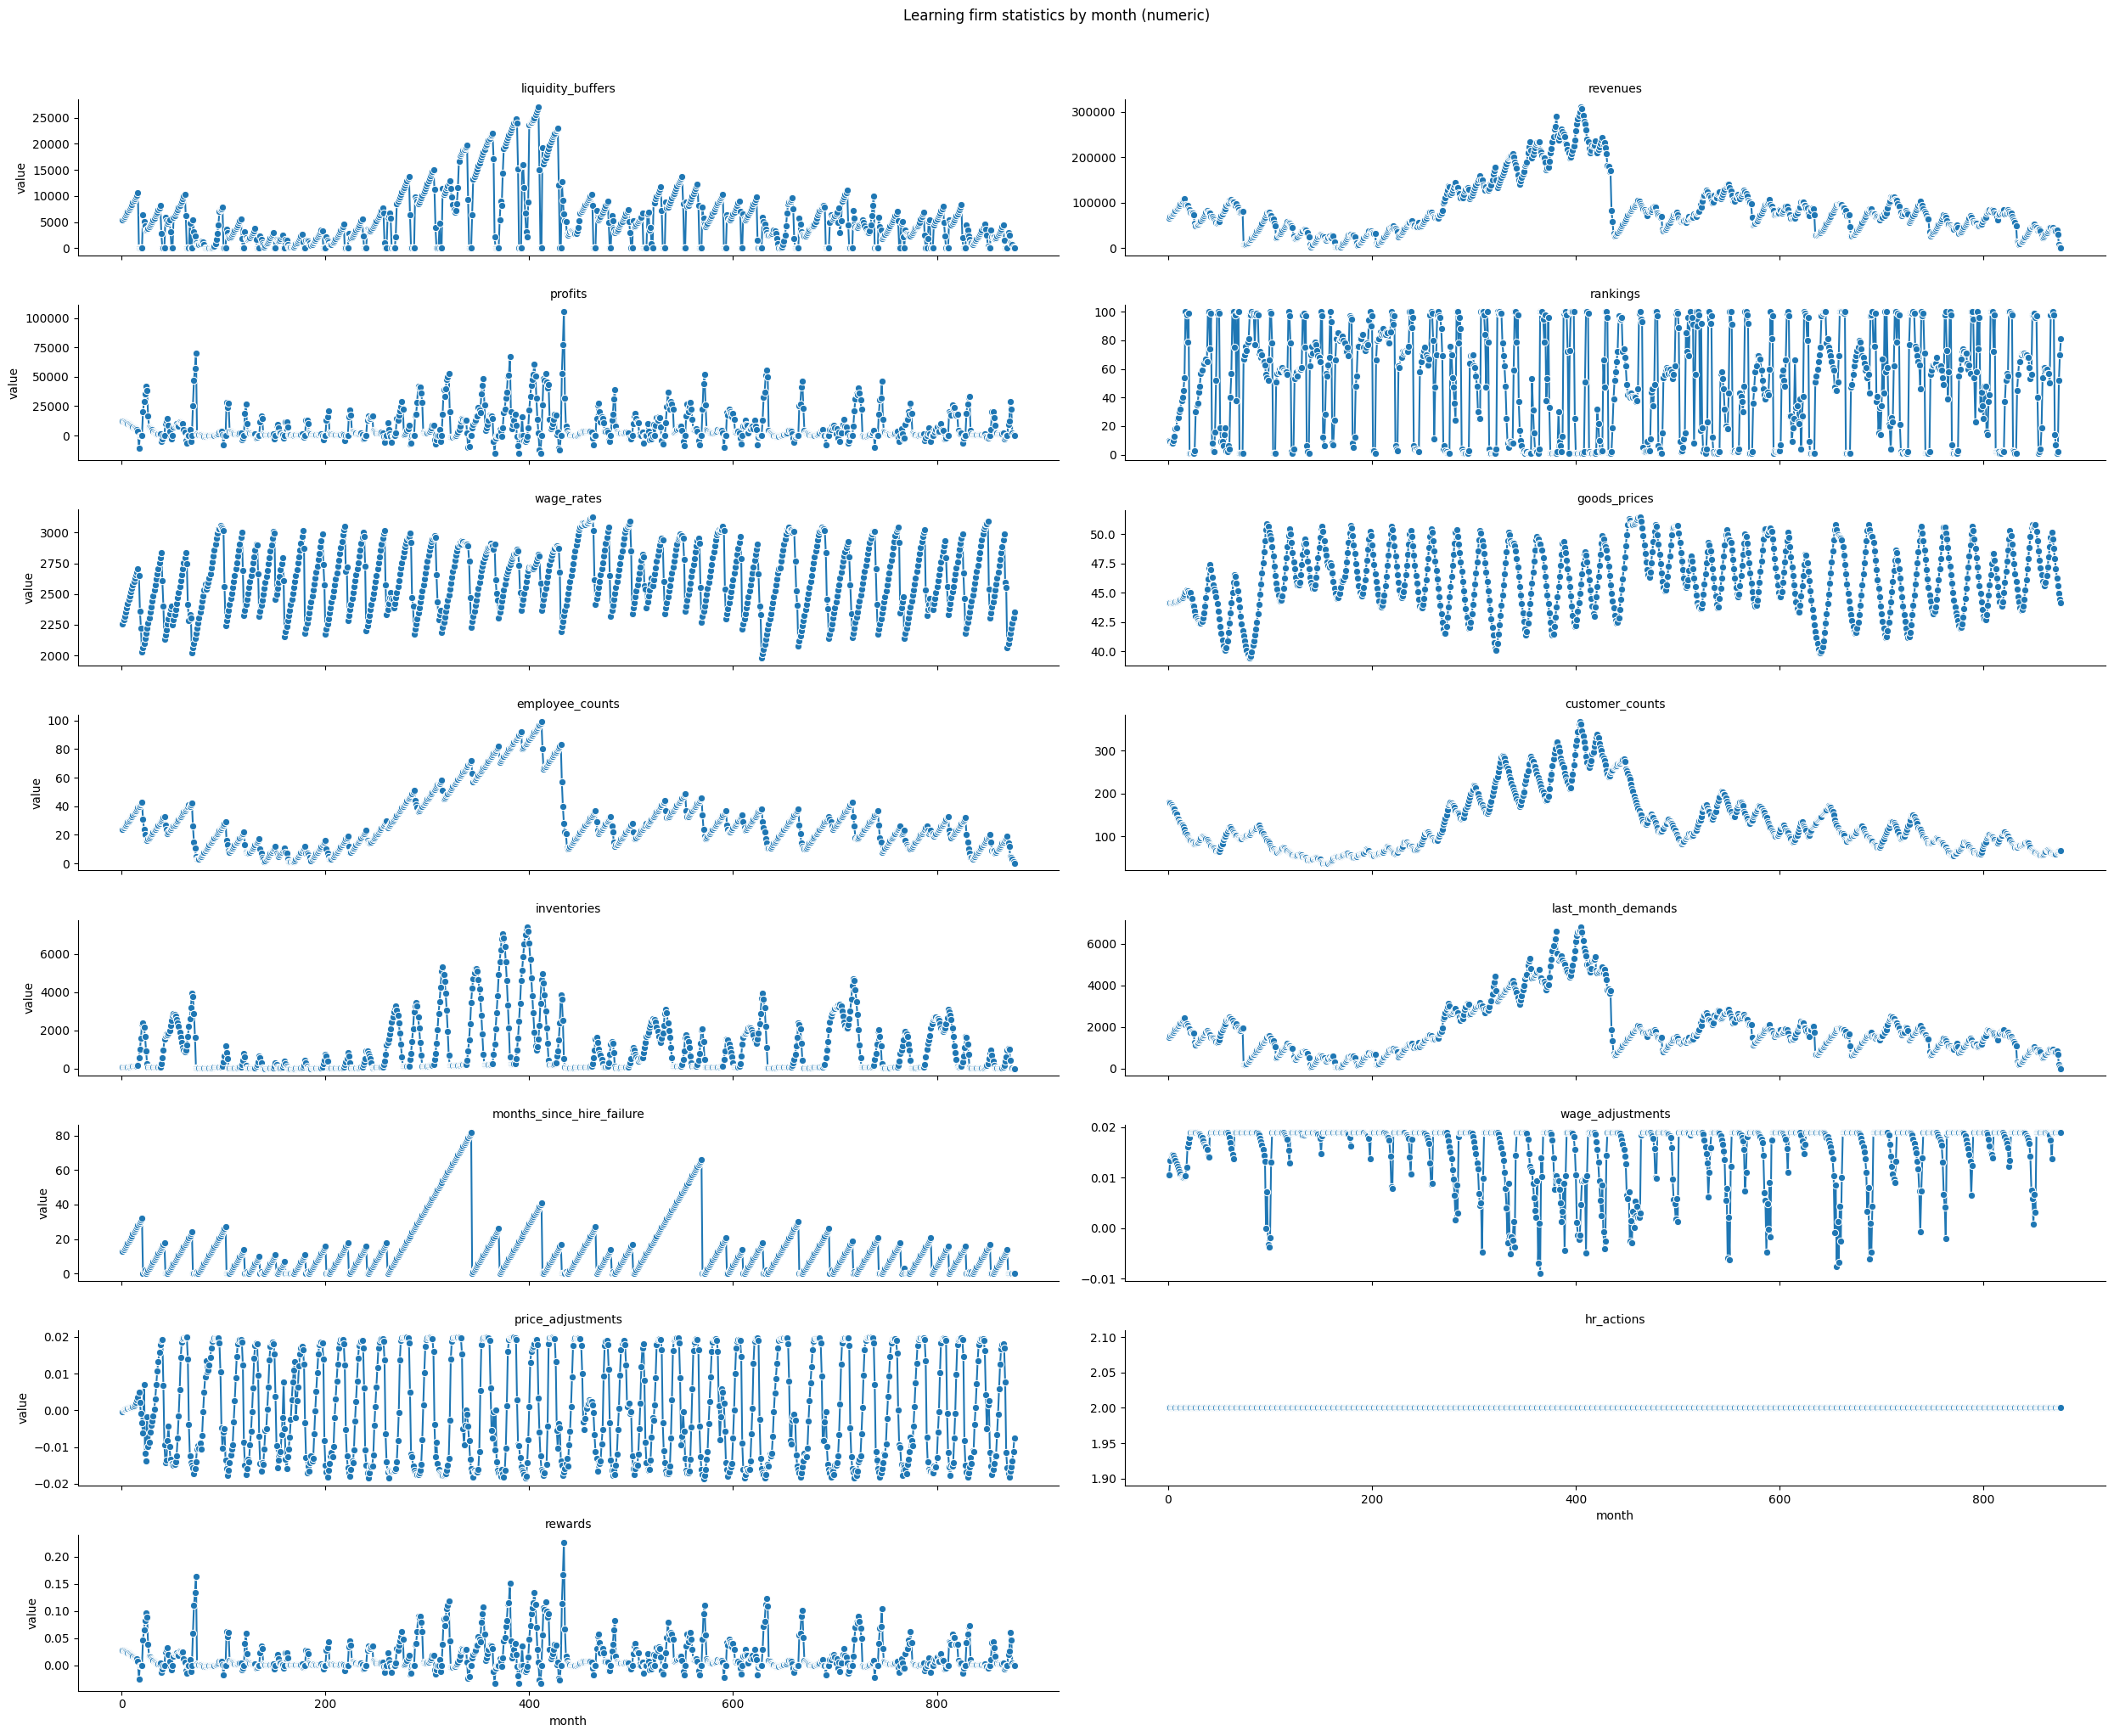

In [26]:
plot_stats(stats[19])

In [20]:
[(f.unique_id, f.goods_price, f.customer_count, f.wage_rate, f.employee_count) for f in models[3].firms]

[(1, 47.74159451896137, 24, 2382.5281051534603, 6),
 (2, 47.718468410145064, 225, 2487.501301783648, 10),
 (3, 47.17937655743458, 139, 2580.0427479543378, 14),
 (4, 48.16284305993126, 20, 2318.1426856404455, 2),
 (5, 47.737271100890474, 11, 2212.554411382984, 2),
 (6, 47.66882584328439, 32, 2407.072397958312, 3),
 (7, 47.971171730392236, 6, 2132.3592992037757, 1),
 (8, 48.1463830567596, 187, 2633.231761039595, 41),
 (9, 47.74382136442528, 112, 2612.205258792806, 22),
 (10, 48.432213472528375, 27, 2137.530126760156, 3),
 (11, 47.025039281715415, 64, 2413.0746522806285, 4),
 (12, 47.211458897800526, 69, 2535.0546373867696, 7),
 (13, 47.43161941345117, 40, 2507.604364597545, 4),
 (14, 47.731913697800856, 20, 2499.0495547194814, 4),
 (15, 48.20142900233266, 43, 2529.4944234805703, 6),
 (16, 46.80948496968873, 28, 2329.729373367053, 4),
 (17, 46.98677718609987, 17, 2026.7853346444424, 0),
 (18, 47.77245959146166, 116, 2543.0567752316847, 18),
 (19, 47.88121110042181, 44, 2382.9229375927566,

In [15]:
stats[3]['rankings'][1000:]

[1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1]